In [1]:
import json
import yaml
import pandas as pd
import seaborn as sns
from pymoo.indicators.hv.exact import ExactHypervolume
from pymoo.indicators.hv.exact_2d import ExactHypervolume2D
from pymoo.indicators.igd_plus import IGDPlus
from pymoo.indicators.hv import HV
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_json(filename):
    try:
        with open(filename, "r") as stream:
            return json.load(stream)
    except:
        filename = filename.replace("json", "yml")
        return read_yaml(filename)

def read_yaml(filename):
    try:
        with open(filename, "r") as stream:
            try:
                return yaml.safe_load(stream)
            except yaml.YAMLError as exc:
                print(exc)
    except:
        return None
    
def add_in_list(dcx, column, value):
    l = dcx.get(column, [])
    l.append(value)
    dcx[column] = l

In [3]:
def dominates(s1, s2):
    better = 0
    eq = 0
    worse = 0
    for i in range(len(s1)):
        if s1[i] < s2[i]:
            better = better + 1
        elif s1[i] == s2[i]:
            eq = eq + 1
        else:
            worse = worse + 1

    if better == len(s1):
        # fullly dominates
        return 1
    if worse == len(s1):
        # fully dominated
        return -1
    if eq == len(s1):
        # exactly the same
        return 0

    if better > 0 and worse == 0:
        # dominates a little
        return 1
    if worse > 0 and better == 0:
        # is dominated a little
        return -1
    return 0


def remove_dominated(pop):
    returning = {}
    for idi, datai in pop.items():
        dominated = False
        for idj, dataj in pop.items():
            if idi != idj:
                if dominates(datai, dataj) == -1:
                    dominated = True
                    break
        if not dominated:
            returning[idi]=datai
    return returning


def normalize(pops, row, obj_name):
    problem_name = row['problem']
    all_solutions = list(pops[problem_name].values())
    if "1" in obj_name:
        min_value_obj = min([el[0] for el in all_solutions])
        max_value_obj = max([el[0] for el in all_solutions])
    elif "2" in obj_name:
        min_value_obj = min([el[1] for el in all_solutions])
        max_value_obj = max([el[1] for el in all_solutions])
        
    value = row[obj_name]
    val = (value - min_value_obj)/(max_value_obj - min_value_obj)
    print(value, min_value_obj,max_value_obj, val)
    return val

    

In [4]:
problems=['CyberShake_100.dot', 'Epigenomics_100.dot', 'Inspiral_100.dot', 'Montage_100.dot', 'Sipht_100.dot', 'Epigenomics_24.dot', 'CyberShake_30.dot', 'Epigenomics_46.dot', 'Inspiral_30.dot', 'Montage_25.dot', 'Sipht_30.dot', 'CyberShake_50.dot', 'Inspiral_50.dot']
#, 'Sipht_60.dot' 'Montage_50.dot'
#problems=['CyberShake_100.dot', 'Epigenomics_100.dot', 'Inspiral_100.dot', 'Montage_100.dot', 'Sipht_100.dot', 'Epigenomics_24.dot', 'CyberShake_30.dot', 'Epigenomics_46.dot', 'Inspiral_30.dot']
algs=['AGEMOEA', 'NSGA2', 'SMSEMOA']

problems=['CyberShake_100.dot', 'Epigenomics_100.dot']
problems=['CyberShake_100.dot', 'Epigenomics_100.dot', "Epigenomics_24.dot","CyberShake_30.dot","Epigenomics_46.dot","Inspiral_30.dot","Montage_25.dot","Sipht_30.dot","CyberShake_50.dot","Sipht_60.dot","Sipht_100.dot"]

heurs=['DLS', 'HCPT', 'HEFT', 'PEFT']
heurs=['DLS', 'HEFT', 'PEFT']
heurs=['HEFT', 'PEFT']
algs=['NSGA2', 'AGEMOEA']
#NSGA2 ['DLS', 'HEFT', 'PEFT'] funciona ate
pop=100
gen=500
qtdExp=10
pops = {}


dire="outputf/"
for problem_name in problems:
    problem_name = problem_name.replace(".dot", "")
    pop = {}
    for algorithm_name in algs:
        for heuristic_name in heurs:
            for execution_id in range(qtdExp):

                filename = (
                        dire
                        + algorithm_name
                        + "_"
                        + str(execution_id)
                        + "_"
                        + problem_name
                        + "_"
                        + heuristic_name
                    )
                data = read_json(filename+".json")
                if data:
                    for idnum, el in enumerate(data['population']):
                        idx = (
                            algorithm_name
                            + "_"
                            + str(execution_id)
                            + "_"
                            + heuristic_name
                            + "_"
                            + str(idnum)    
                        )
                        #el['F'][1] = el['F'][1] * 3600
                        pop[idx] = el['F']
                        
                filename = (
                        'resp2/'
                        + problem_name
                        + '_pysim'
                )
                data = read_json(filename+".json")
                for id_sol, solution in enumerate(data):
                    idx = (
                        'NSGA2'
                        + "_"
                        + str(666)
                        + "_"
                        + "Zhu"
                        + "_"
                        + str(id_sol)    
                    )
                    pop[idx] = solution[1:3]
    pops[problem_name] = pop

In [5]:
nds = {}
for problem, pop in pops.items():
    nds[problem]=remove_dominated(pop)
    #nds[problem]=pop
    print(len(nds[problem]))

475
464
1584
1821
1527
1866
2282
523
562
532
201


In [6]:
pop

{'NSGA2_0_HEFT_0': [62.49502572157988, 3.7399999999999998],
 'NSGA2_0_HEFT_1': [41.02983915252166, 5.1],
 'NSGA2_0_HEFT_2': [62.38286348268812, 3.91],
 'NSGA2_0_HEFT_3': [40.88834740261959, 5.27],
 'NSGA2_0_HEFT_4': [11.42955765206571, 29.410000000000032],
 'NSGA2_0_HEFT_5': [11.42955253356468, 33.66000000000004],
 'NSGA2_0_HEFT_6': [12.756641445432587, 21.930000000000017],
 'NSGA2_0_HEFT_7': [15.18774391511094, 15.299999999999999],
 'NSGA2_0_HEFT_8': [11.429555236935814, 30.090000000000025],
 'NSGA2_0_HEFT_9': [15.187743728939806, 15.809999999999999],
 'NSGA2_0_HEFT_10': [13.776860998906951, 17.85000000000002],
 'NSGA2_0_HEFT_11': [18.763369623041275, 14.45],
 'NSGA2_0_HEFT_12': [11.429549005564681, 35.02000000000004],
 'NSGA2_0_HEFT_13': [15.187741789427433, 15.81],
 'NSGA2_0_HEFT_14': [11.429560633026536, 27.030000000000015],
 'NSGA2_0_HEFT_15': [11.64955174846289, 22.78000000000001],
 'NSGA2_0_HEFT_16': [23.149299836304078, 10.709999999999999],
 'NSGA2_0_HEFT_17': [13.1326561307009

In [7]:
dcx={}
for problem in problems:
    problem = problem.replace('.dot','')
    for ids, data in nds[problem].items():
        id_arr = ids.split('_')
        add_in_list(dcx, 'alg', id_arr[0])
        add_in_list(dcx, 'heu', id_arr[2])
        add_in_list(dcx, 'problem', problem)
        add_in_list(dcx, 'exec', int(id_arr[1]))
        add_in_list(dcx, 'obj1', data[0])
        add_in_list(dcx, 'obj2', data[1])
        

In [8]:
df =pd.DataFrame(dcx)
df['algorithm']=df['alg']+"_"+df['heu']
df['obj1_n']=df.apply(lambda row : normalize(pops, row, 'obj1'), axis=1)
df['obj2_n']=df.apply(lambda row : normalize(pops, row, 'obj2'), axis=1)

57.87160587442885 3.5657082864280087 1768.2628455921965 0.030773494465408245
42.228480511112494 3.5657082864280087 1768.2628455921965 0.021909012831353283
34.39313876326449 3.5657082864280087 1768.2628455921965 0.017468963838124605
15.04499519165356 3.5657082864280087 1768.2628455921965 0.0065049614818049875
13.16691849937573 3.5657082864280087 1768.2628455921965 0.005440712748934505
15.937115463816392 3.5657082864280087 1768.2628455921965 0.007010498807900991
21.148689556915528 3.5657082864280087 1768.2628455921965 0.009963738762183372
11.193288557985825 3.5657082864280087 1768.2628455921965 0.004322316906573067
12.5006309174933 3.5657082864280087 1768.2628455921965 0.005063147914835167
17.307237312113685 3.5657082864280087 1768.2628455921965 0.007786905036104609
29.708047440471784 3.5657082864280087 1768.2628455921965 0.014814065598789544
18.261066155790207 3.5657082864280087 1768.2628455921965 0.008327410726011699
22.645549481706297 3.5657082864280087 1768.2628455921965 0.0108119635

7.719441918890508 3.5657082864280087 1768.2628455921965 0.0023537940560181135
4.483440031859175 3.5657082864280087 1768.2628455921965 0.0005200505662021431
4.226728963174339 3.5657082864280087 1768.2628455921965 0.0003745802397319781
4.838202858916438 3.5657082864280087 1768.2628455921965 0.0007210838310936437
3.76626786608281 3.5657082864280087 1768.2628455921965 0.00011365099167158126
4.682544200667539 3.5657082864280087 1768.2628455921965 0.0006328768209737374
3.824220135427822 3.5657082864280087 1768.2628455921965 0.00014649077370550568
4.445437557066278 3.5657082864280087 1768.2628455921965 0.0004985157237696807
4.121433395598561 3.5657082864280087 1768.2628455921965 0.00031491245575373855
4.006693483172412 3.5657082864280087 1768.2628455921965 0.0002498928498391923
3.74456019702223 3.5657082864280087 1768.2628455921965 0.0001013499182456211
4.724132228891182 3.5657082864280087 1768.2628455921965 0.0006564434870857123
8.138003945350867 3.5657082864280087 1768.2628455921965 0.00259

3.8317999415056856 3.5657082864280087 1768.2628455921965 0.0001507860184348286
4.018314783379735 3.5657082864280087 1768.2628455921965 0.0002564782859243132
3.742799208514219 3.5657082864280087 1768.2628455921965 0.00010035201981263584
4.215645025547969 3.5657082864280087 1768.2628455921965 0.00036829931061838983
5.106126729128257 3.5657082864280087 1768.2628455921965 0.0008729081099162799
4.03601295554647 3.5657082864280087 1768.2628455921965 0.0002665072998511764
3.6507934908368944 3.5657082864280087 1768.2628455921965 4.8215188096688675e-05
4.709580091669489 3.5657082864280087 1768.2628455921965 0.0006481972351288978
3.9467919641754157 3.5657082864280087 1768.2628455921965 0.00021594848752869974
4.000525436246597 3.5657082864280087 1768.2628455921965 0.00024639760592712253
4.125602053263228 3.5657082864280087 1768.2628455921965 0.0003172747068032484
4.043039660166555 3.5657082864280087 1768.2628455921965 0.0002704891188679017
4.106149477475423 3.5657082864280087 1768.2628455921965 0

266.2686996805347 84.34406912999576 6801.22892296136 0.02708467310508795
167.64126354601086 84.34406912999576 6801.22892296136 0.012401164561947451
616.8067917287026 84.34406912999576 6801.22892296136 0.07927227192155689
440.4050970809238 84.34406912999576 6801.22892296136 0.053009845441645165
1053.6002699765406 84.34406912999576 6801.22892296136 0.1443014465691895
1484.6312849409564 84.34406912999576 6801.22892296136 0.2084727141052933
105.94253931162497 84.34406912999576 6801.22892296136 0.003215548673476109
1090.005513777092 84.34406912999576 6801.22892296136 0.14972140605826506
302.87386556440185 84.34406912999576 6801.22892296136 0.03253439670173219
95.75259906531788 84.34406912999576 6801.22892296136 0.001698485262675689
396.61147621066146 84.34406912999576 6801.22892296136 0.04648991517288641
647.1177154259101 84.34406912999576 6801.22892296136 0.08378491794077783
413.01069172042065 84.34406912999576 6801.22892296136 0.04893140640976611
187.4462476065523 84.34406912999576 6801.2

318.64544079830864 84.34406912999576 6801.22892296136 0.034882445771668324
1655.5102672011467 84.34406912999576 6801.22892296136 0.23391292723664087
99.03669603501486 84.34406912999576 6801.22892296136 0.002187416819664298
136.78867768585224 84.34406912999576 6801.22892296136 0.007807876671570699
100.32431421683303 84.34406912999576 6801.22892296136 0.0023791155326597585
100.32431421683303 84.34406912999576 6801.22892296136 0.0023791155326597585
265.17534306344936 84.34406912999576 6801.22892296136 0.026921895769927633
961.4080402941105 84.34406912999576 6801.22892296136 0.13057600215728435
237.2113378104094 84.34406912999576 6801.22892296136 0.022758655538544323
2052.979034663296 84.34406912999576 6801.22892296136 0.2930874964173869
3515.2874947602654 84.34406912999576 6801.22892296136 0.5107938427250591
2709.1290216321286 84.34406912999576 6801.22892296136 0.3907741474837007
3501.3464206395543 84.34406912999576 6801.22892296136 0.5087183159854934
3388.454321539288 84.34406912999576 6

...

2.72 0.085 98.268 0.026837639917297294
5.61 0.085 98.268 0.05627247079433303
2.72 0.085 98.268 0.026837639917297294
6.12 0.085 98.268 0.06146685271380992
4.08 0.085 98.268 0.04068932503590234
7.65 0.085 98.268 0.07704999847224062
8.67 0.085 98.268 0.08743876231119439
8.16 0.085 98.268 0.0822443803917175
8.67 0.085 98.268 0.08743876231119439
20.4 0.085 98.268 0.20690954645916296
20.4 0.085 98.268 0.20690954645916296
2.04 0.085 98.268 0.019911797357994764
2.04 0.085 98.268 0.019911797357994764
0.255 0.085 98.268 0.0017314606398256315
1.53 0.085 98.268 0.014717415438517869
1.53 0.085 98.268 0.014717415438517869
0.17 0.085 98.268 0.0008657303199128158
0.17 0.085 98.268 0.0008657303199128158
1.53 0.085 98.268 0.014717415438517869
1.53 0.085 98.268 0.014717415438517869
5.61 0.085 98.268 0.05627247079433303
5.61 0.085 98.268 0.05627247079433303
8.67 0.085 98.268 0.08743876231119439
6.12 0.085 98.268 0.06146685271380992
6.12 0.085 98.268 0.06146685271380992
4.08 0.085 98.268 0.0406893250359023

1.7 0.17 119.301 0.01284300475946647
5.27 0.17 119.301 0.04281001586488823
4.25 0.17 119.301 0.034248012691910586
2.89 0.17 119.301 0.022832008461273725
6.12 0.17 119.301 0.04994501850903627
1.36 0.17 119.301 0.009989003701807256
1.53 0.17 119.301 0.011416004230636862
2.72 0.17 119.301 0.02140500793244412
3.5700000000000003 0.17 119.301 0.028540010576592157
5.61 0.17 119.301 0.04566401692254745
5.78 0.17 119.301 0.04709101745137706
6.29 0.17 119.301 0.05137201903786588
5.609999999999999 0.17 119.301 0.04566401692254744
2.295 0.17 119.301 0.017837506610370098
0.17 0.17 119.301 0.0
0.595 0.17 119.301 0.0035675013220740188
2.125 0.17 119.301 0.016410506081540488
0.255 0.17 119.301 0.0007135002644148038
1.7 0.17 119.301 0.01284300475946647
2.89 0.17 119.301 0.022832008461273725
0.8500000000000001 0.17 119.301 0.005708002115318431
1.7 0.17 119.301 0.01284300475946647
4.25 0.17 119.301 0.034248012691910586
6.29 0.17 119.301 0.05137201903786588
2.72 0.17 119.301 0.02140500793244412
1.53 0.17 

0.21400000000000002 0.085 147.743 0.0008736404393937343
0.384 0.085 147.743 0.0020249495455715236
0.358 0.085 147.743 0.001848866976391391
0.302 0.085 147.743 0.0014696122120034132
0.314 0.085 147.743 0.0015508810900865513
3.67 0.085 147.743 0.024279077327337497
1.53 0.085 147.743 0.009786127402511209
39.099999999999994 0.085 147.743 0.2642254398678026
26.86 0.085 147.743 0.18133118422300182
22.61 0.085 147.743 0.15254845656855706
8.33 0.085 147.743 0.055838491649622776
9.01 0.085 147.743 0.06044372807433393
9.69 0.085 147.743 0.06504896449904508
15.809999999999999 0.085 147.743 0.1064960923214455
30.644 0.085 147.743 0.206957970445218
31.79 0.085 147.743 0.2147191483021577
21.93 0.085 147.743 0.14794322014384592
13.392 0.085 147.743 0.09012041338769318
12.498 0.085 147.743 0.0840658819704994
14.707999999999998 0.085 147.743 0.09903290035081065
16.747999999999998 0.085 147.743 0.11284860962494411
17.85 0.085 147.743 0.12031180159557898
11.943999999999999 0.085 147.743 0.080313968765661

3.06 0.085 147.743 0.020147909358111313
17.85 0.085 147.743 0.12031180159557898
2.55 0.085 147.743 0.016693982039577945
5.824 0.085 147.743 0.03886684094326078
0.42500000000000004 0.085 147.743 0.0023026182123555786
4.165 0.085 147.743 0.027631418548266944
0.51 0.085 147.743 0.0028782727654444733
0.595 0.085 147.743 0.003453927318533368
1.105 0.085 147.743 0.006907854637066736
0.6799999999999999 0.085 147.743 0.004029581871622262
1.5299999999999998 0.085 147.743 0.009786127402511209
0.935 0.085 147.743 0.0057565455308889475
1.3599999999999999 0.085 147.743 0.008634818296333419
1.3599999999999997 0.085 147.743 0.008634818296333419
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530888947
0.17 0.085 147.743 0.0005756545530

0.765 0.17 268.42799999999994 0.0022180140014463694
0.935 0.17 268.42799999999994 0.0028517322875739035
0.34 0.17 268.42799999999994 0.0006337182861275341
0.51 0.17 268.42799999999994 0.001267436572255068
1.02 0.17 268.42799999999994 0.0031685914306376706
1.7 0.17 268.42799999999994 0.005703464575147807
0.68 0.17 268.42799999999994 0.0019011548583826024
1.8699999999999999 0.17 268.42799999999994 0.006337182861275341
0.8500000000000001 0.17 268.42799999999994 0.0025348731445101365
4.59 0.17 268.42799999999994 0.016476675439315885
4.76 0.17 268.42799999999994 0.017110393725443422
12.579999999999998 0.17 268.42799999999994 0.046261434887309986
12.919999999999998 0.17 268.42799999999994 0.04752887145956505
7.6499999999999995 0.17 268.42799999999994 0.027883604589611498
9.52 0.17 268.42799999999994 0.034854505737014374
9.18 0.17 268.42799999999994 0.03358706916475931
12.579999999999998 0.17 268.42799999999994 0.046261434887309986
11.559999999999999 0.17 268.42799999999994 0.0424591251705447

In [10]:
df[df.problem=='CyberShake_30'].alg.unique()

array(['NSGA2', 'AGEMOEA'], dtype=object)

In [11]:
df.problem.unique()

array(['CyberShake_100', 'Epigenomics_100', 'Epigenomics_24',
       'CyberShake_30', 'Epigenomics_46', 'Inspiral_30', 'Montage_25',
       'Sipht_30', 'CyberShake_50', 'Sipht_60', 'Sipht_100'], dtype=object)

<AxesSubplot:xlabel='obj1', ylabel='obj2'>

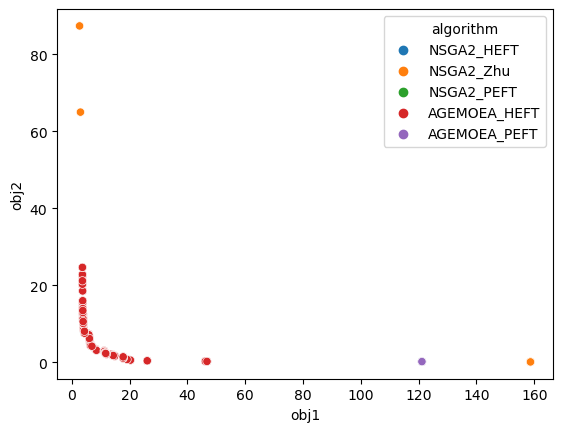

In [13]:
sns.scatterplot(df[df['problem']=='CyberShake_30'], x='obj1', y='obj2', hue='algorithm')

In [14]:
df[df.problem == 'CyberShake_30'].median()

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/872395805.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df[df.problem == 'CyberShake_30'].median()


exec      5.000000
obj1      6.505224
obj2      4.420000
obj1_n    0.004907
obj2_n    0.044440
dtype: float64

In [15]:
df[df.problem == 'CyberShake_30']

,alg,heu,problem,exec,obj1,obj2,algorithm,obj1_n,obj2_n
2523,NSGA2,HEFT,CyberShake_30,0,46.796994,0.214,NSGA2_HEFT,0.057266,0.001322
2524,NSGA2,HEFT,CyberShake_30,0,8.215136,3.444,NSGA2_HEFT,0.007129,0.034435
2525,NSGA2,HEFT,CyberShake_30,0,26.134234,0.384,NSGA2_HEFT,0.030414,0.003065
2526,NSGA2,HEFT,CyberShake_30,0,17.801238,1.404,NSGA2_HEFT,0.019586,0.013522
2527,NSGA2,HEFT,CyberShake_30,0,17.801804,1.064,NSGA2_HEFT,0.019586,0.010036
...,...,...,...,...,...,...,...,...,...
4339,AGEMOEA,PEFT,CyberShake_30,5,121.143248,0.170,AGEMOEA_PEFT,0.153879,0.000871
4340,AGEMOEA,PEFT,CyberShake_30,6,121.143248,0.170,AGEMOEA_PEFT,0.153879,0.000871
4341,AGEMOEA,PEFT,CyberShake_30,7,121.143248,0.170,AGEMOEA_PEFT,0.153879,0.000871
4342,AGEMOEA,PEFT,CyberShake_30,8,121.143248,0.170,AGEMOEA_PEFT,0.153879,0.000871


In [16]:
problems = df.problem.unique()

In [17]:
algorithms = df.algorithm.unique()

In [18]:
execs = df.exec.unique()

In [19]:
results = pd.DataFrame({'Hypervolume': [], 'problem':[], 'alg':[], 'exec':[], 'igd':[]})
for problem in problems:
    ref_point = np.array([1, 1])
    ind_hv = HV(ref_point=ref_point)
    sub_data = df[(df.problem==problem)]
    pf = np.array(list(zip(sub_data['obj1_n'], sub_data['obj2_n'])))
    ind_igd = IGDPlus(pf)
    for alg in algorithms:
        for execn in execs:
            sub_data = df[(df.problem==problem) & (df.algorithm==alg) & (df.exec==execn)]
            if sub_data.shape[0] > 0:
                sac = sub_data
                A=np.array(list(zip(sac['obj1_n'], sac['obj2_n'])))
                hv_value= ind_hv(A)
                igd_value= ind_igd(A)
            else:
                hv_value= 0
                igd_value= 1
                #hv_value= None
                #igd_value= None
            results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)


Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False



/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

...

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':problem, 'alg':alg, 'exec':execn}, ignore_index=True)
/var/folders/gm/mf9q_3212qq760gs60q5yl6c0000gn/T/ipykernel_81126/3943487955.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append({'Hypervolume': hv_value, 'igd':igd_value, 'problem':prob

In [20]:
results=results[(results.exec <= 20) | (results.alg=='NSGA2_Zhu')]

In [21]:
results

,Hypervolume,problem,alg,exec,igd
0,0.999041,CyberShake_100,NSGA2_HEFT,0.0,0.000233
2,0.998898,CyberShake_100,NSGA2_HEFT,1.0,0.000190
3,0.998355,CyberShake_100,NSGA2_HEFT,2.0,0.000208
4,0.999207,CyberShake_100,NSGA2_HEFT,3.0,0.000193
5,0.999204,CyberShake_100,NSGA2_HEFT,4.0,0.000125
...,...,...,...,...,...
600,0.000000,Sipht_100,AGEMOEA_PEFT,5.0,1.000000
601,0.000000,Sipht_100,AGEMOEA_PEFT,6.0,1.000000
602,0.000000,Sipht_100,AGEMOEA_PEFT,7.0,1.000000
603,0.000000,Sipht_100,AGEMOEA_PEFT,8.0,1.000000


In [22]:
grouped_results = results.groupby(['problem', 'alg']).mean().reset_index()

In [23]:
grouped_results

,problem,alg,Hypervolume,exec,igd
0,CyberShake_100,AGEMOEA_HEFT,0.000000,4.500000,1.000000
1,CyberShake_100,AGEMOEA_PEFT,0.000000,4.500000,1.000000
2,CyberShake_100,NSGA2_HEFT,0.998817,4.500000,0.000230
3,CyberShake_100,NSGA2_PEFT,0.000000,4.500000,1.000000
4,CyberShake_100,NSGA2_Zhu,0.075905,64.636364,0.922756
5,CyberShake_30,AGEMOEA_HEFT,0.996659,4.500000,0.000023
6,CyberShake_30,AGEMOEA_PEFT,0.845384,4.500000,0.141254
7,CyberShake_30,NSGA2_HEFT,0.996659,4.500000,0.000023
8,CyberShake_30,NSGA2_PEFT,0.845384,4.500000,0.141254
9,CyberShake_30,NSGA2_Zhu,0.078642,64.636364,0.926298


In [83]:
analise=results[(results['problem']=='CyberShake_100') & (results['alg']=='AGEMOEA_PEFT')]

In [84]:
analise[analise.Hypervolume>0]

,Hypervolume,problem,alg,exec,igd


In [24]:
import seaborn as sns

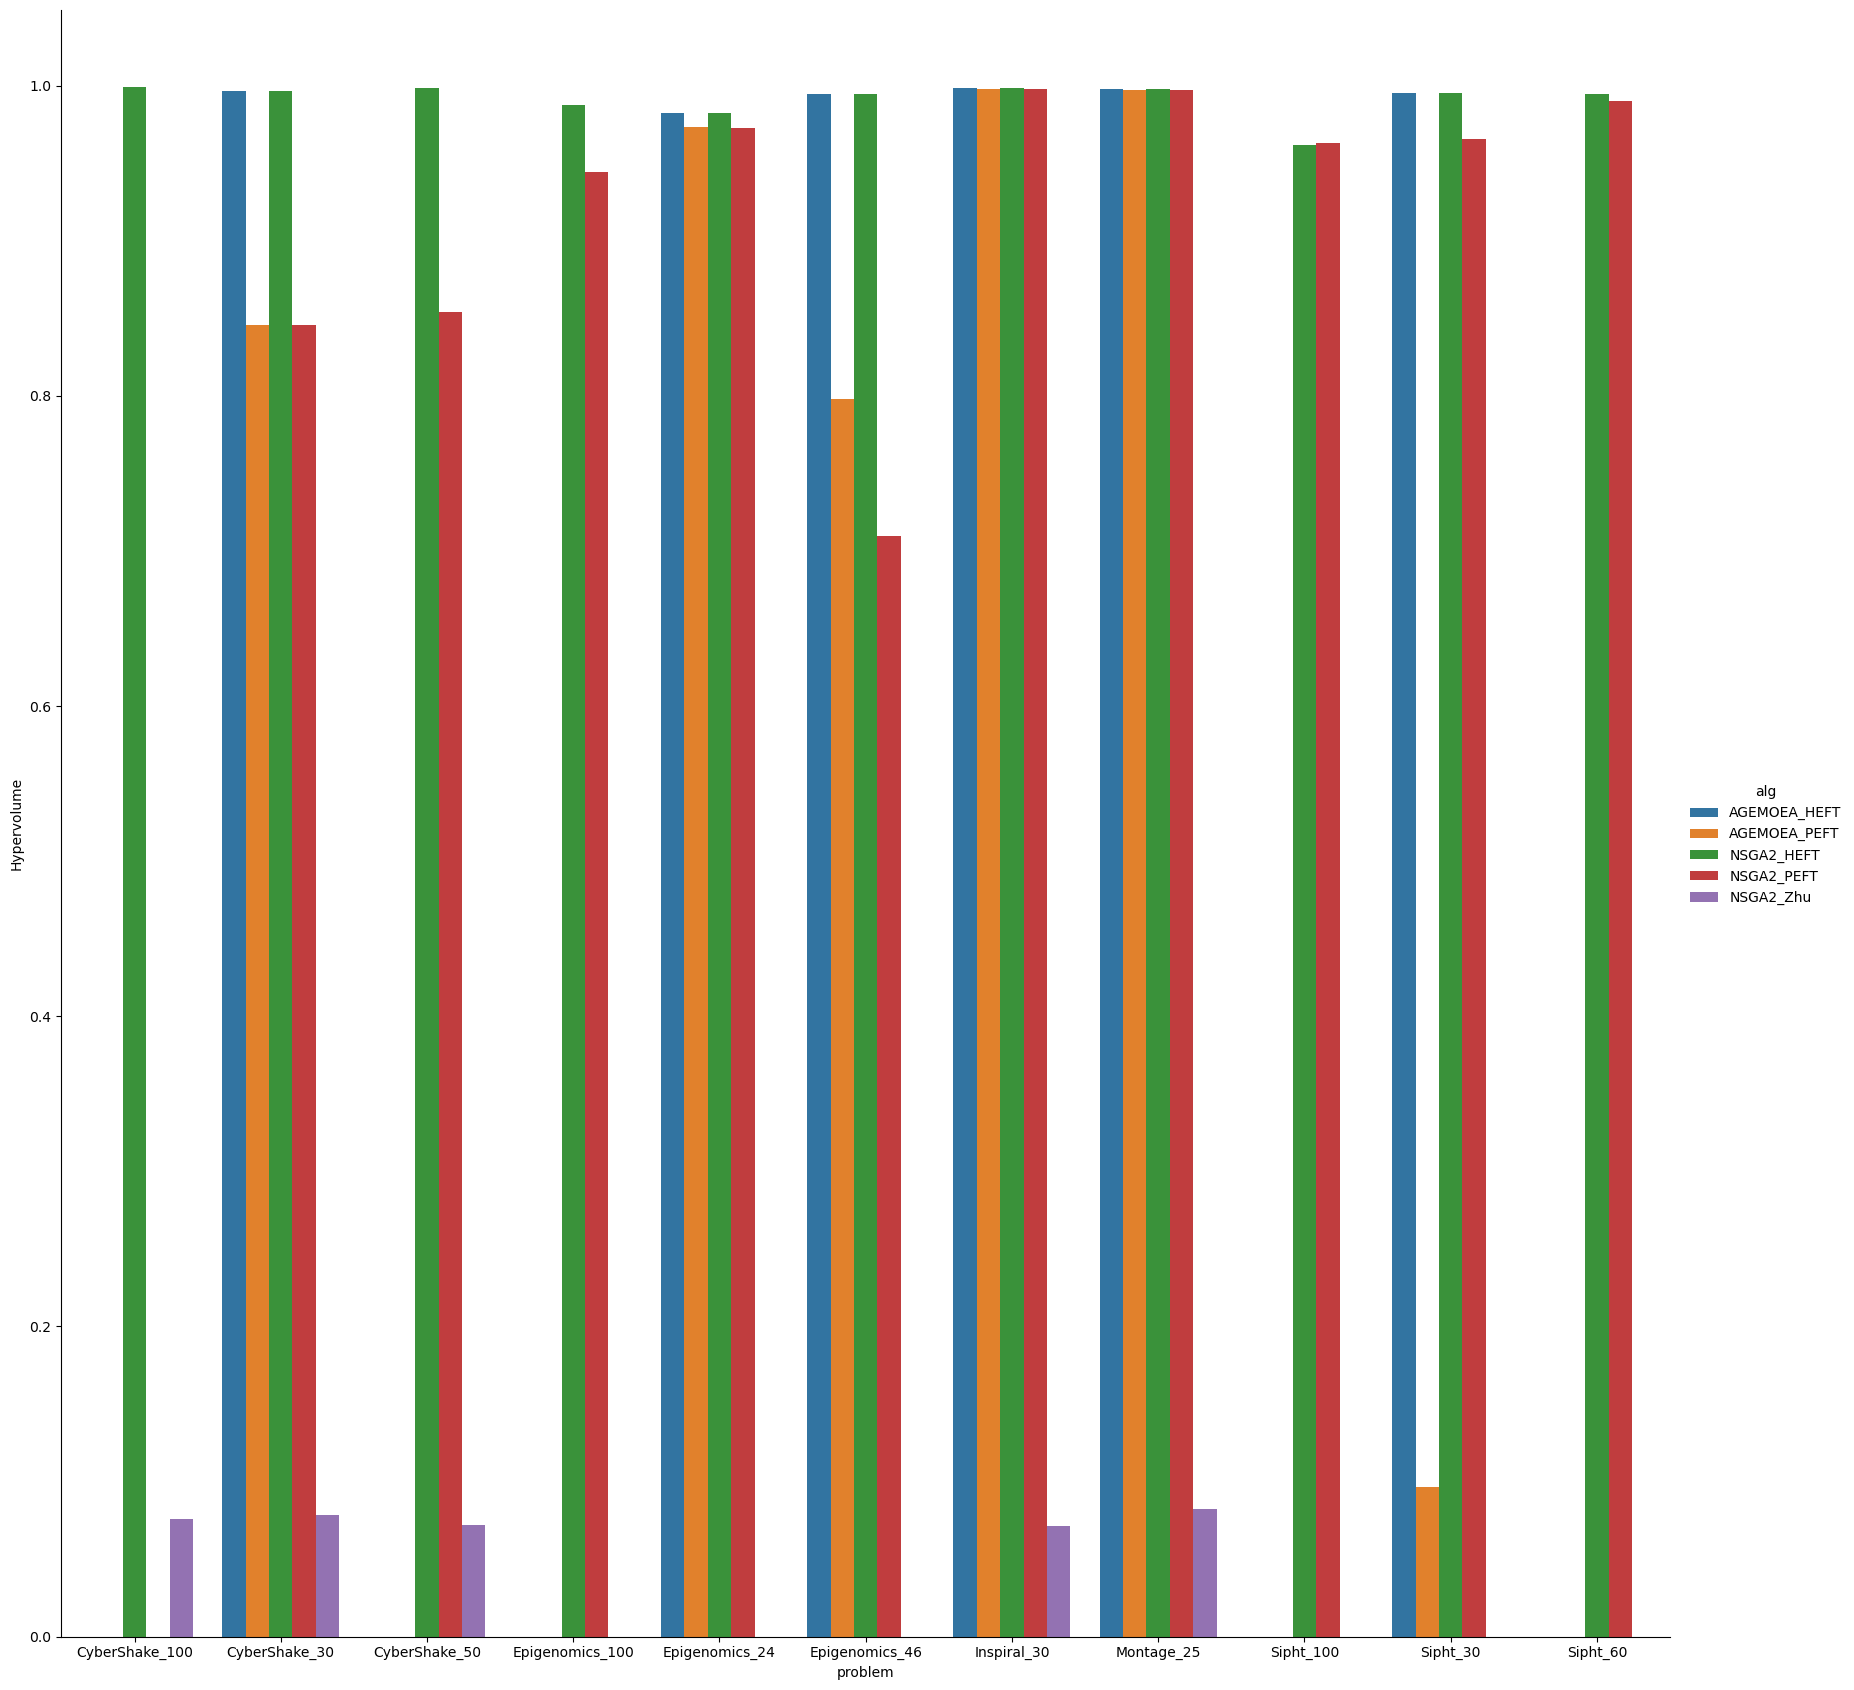

In [25]:
#a4_dims = (11.7, 8.27)
#from matplotlib import pyplot
#fig, ax = pyplot.subplots(figsize=a4_dims)

sns.catplot(x='problem', y='Hypervolume', hue='alg', data=grouped_results, kind='bar', height=17, aspect=1)

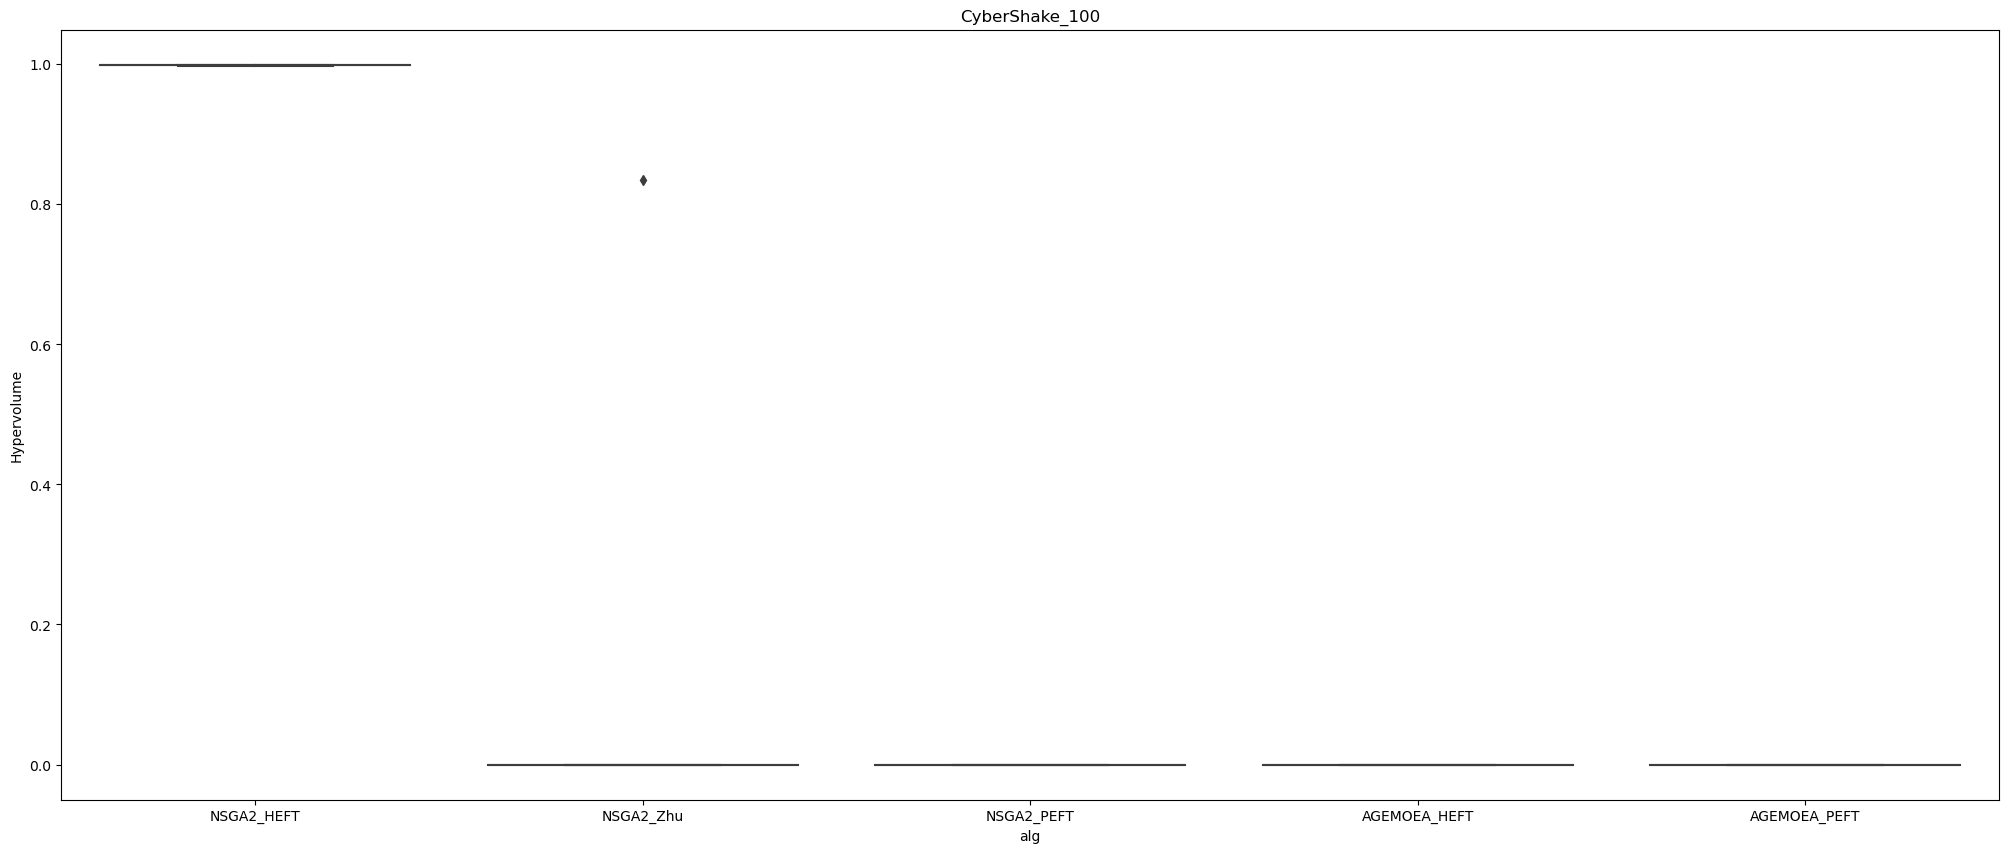

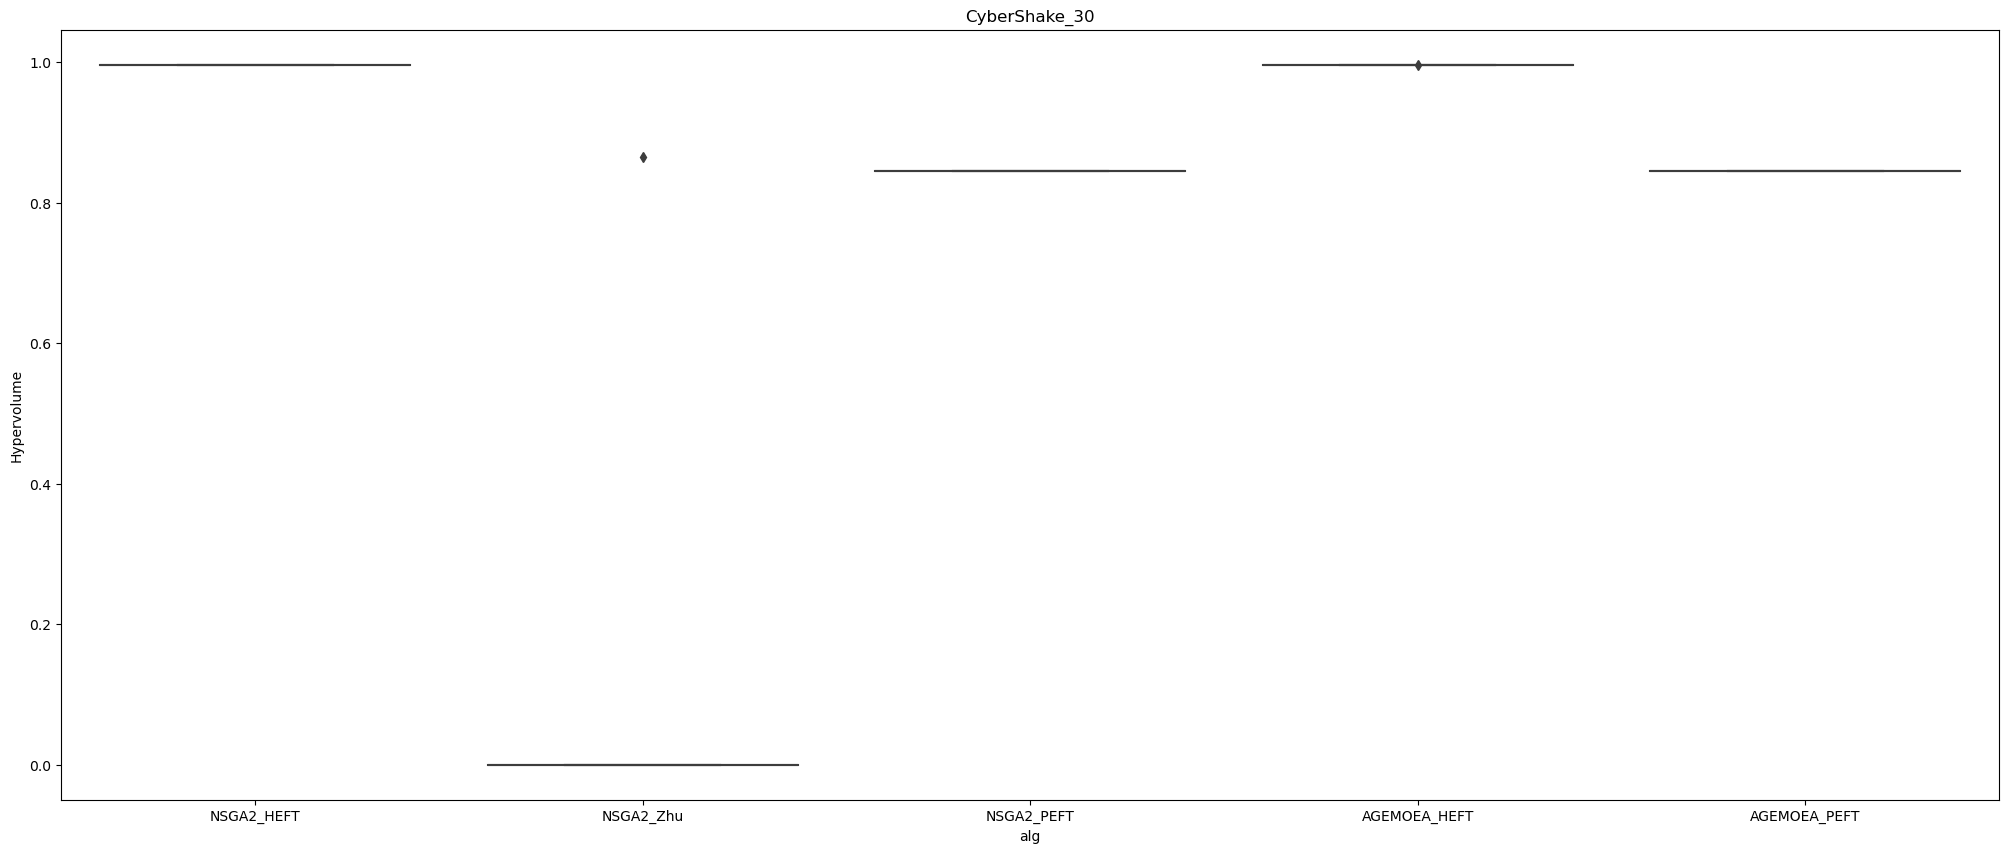

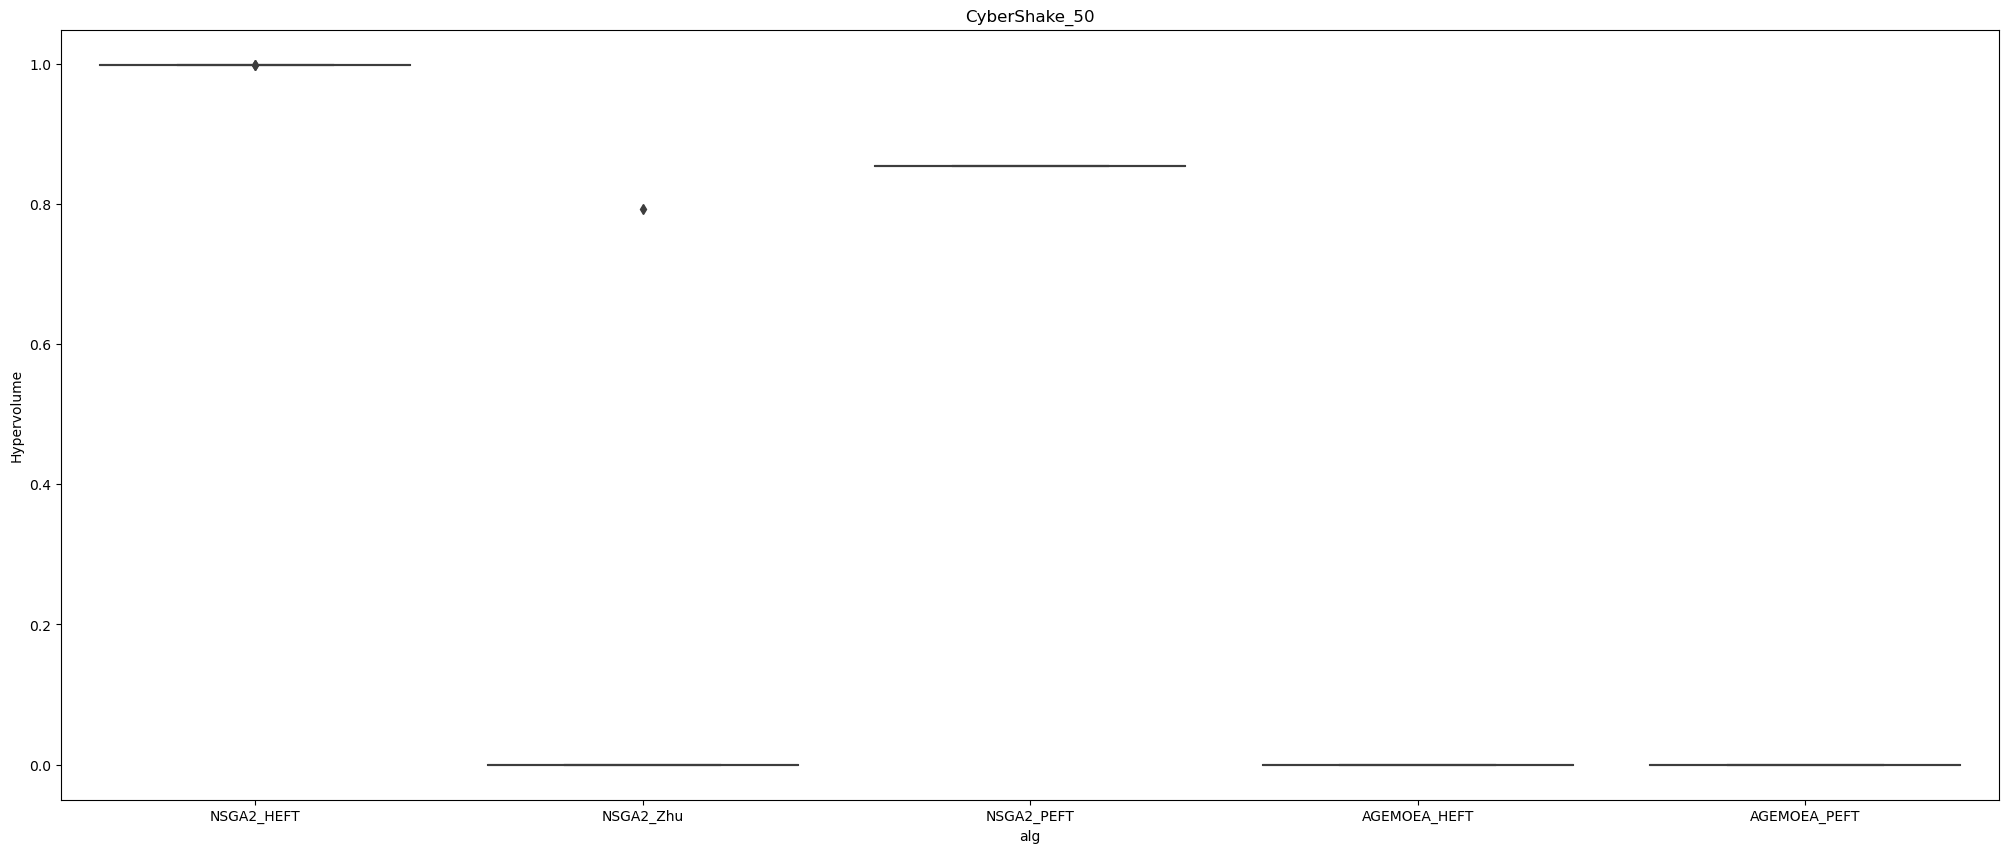

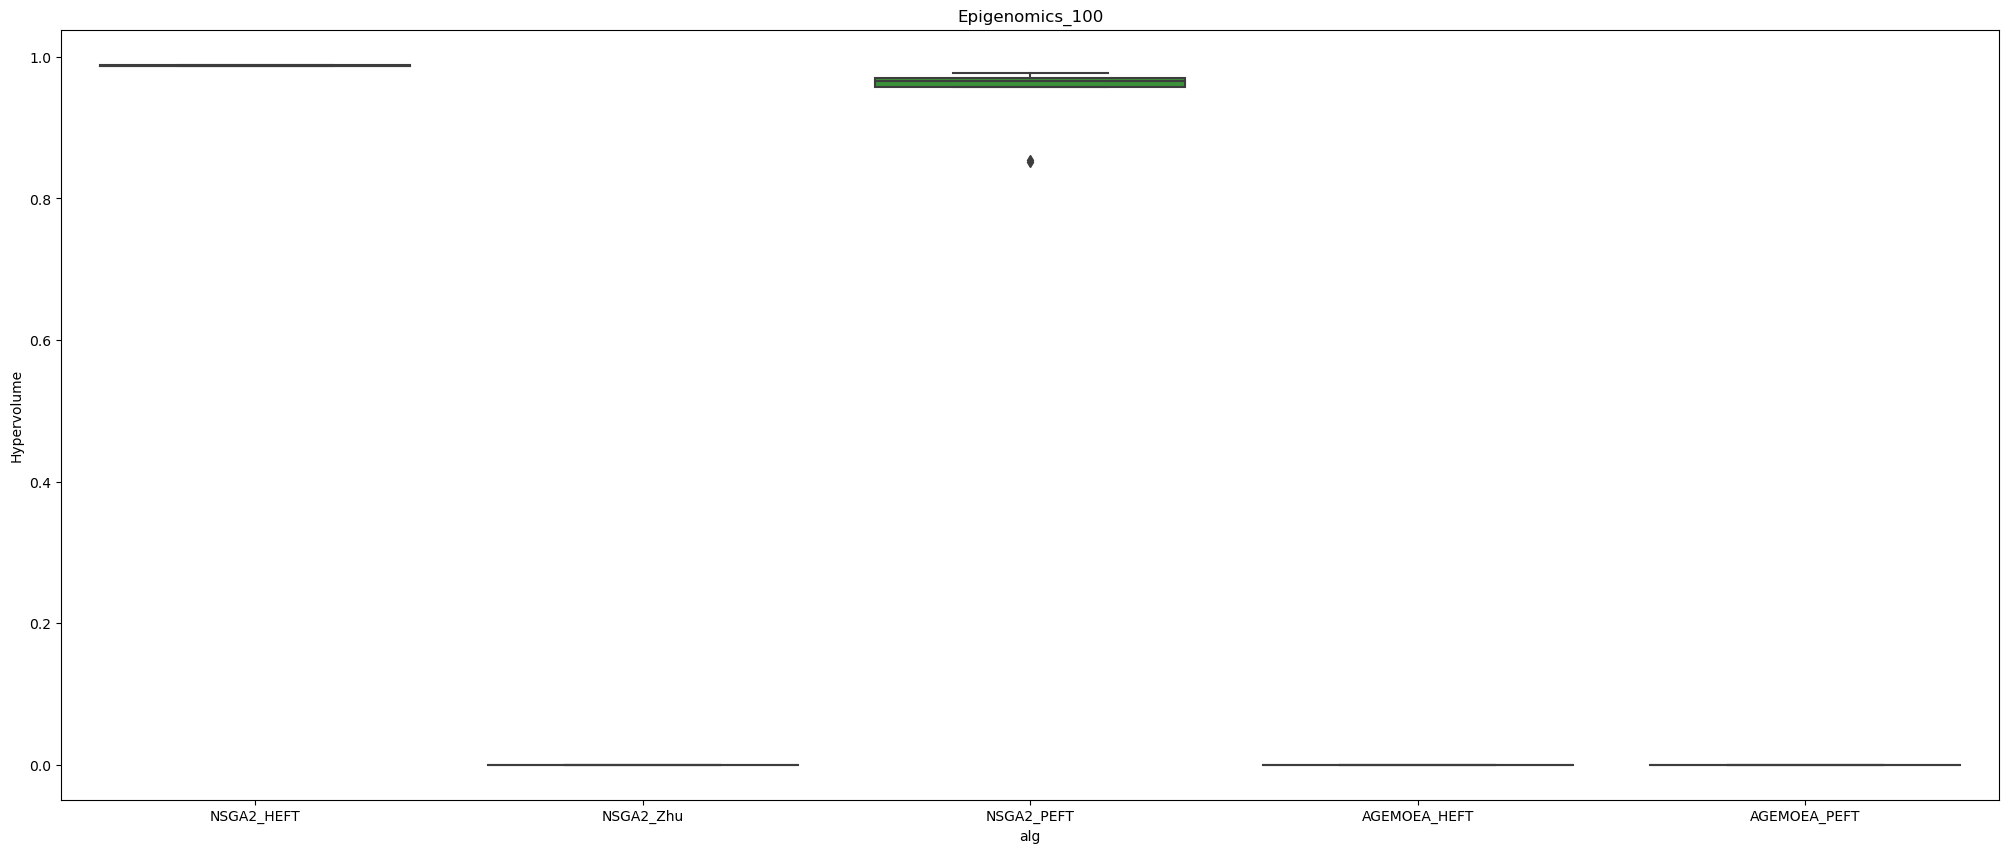

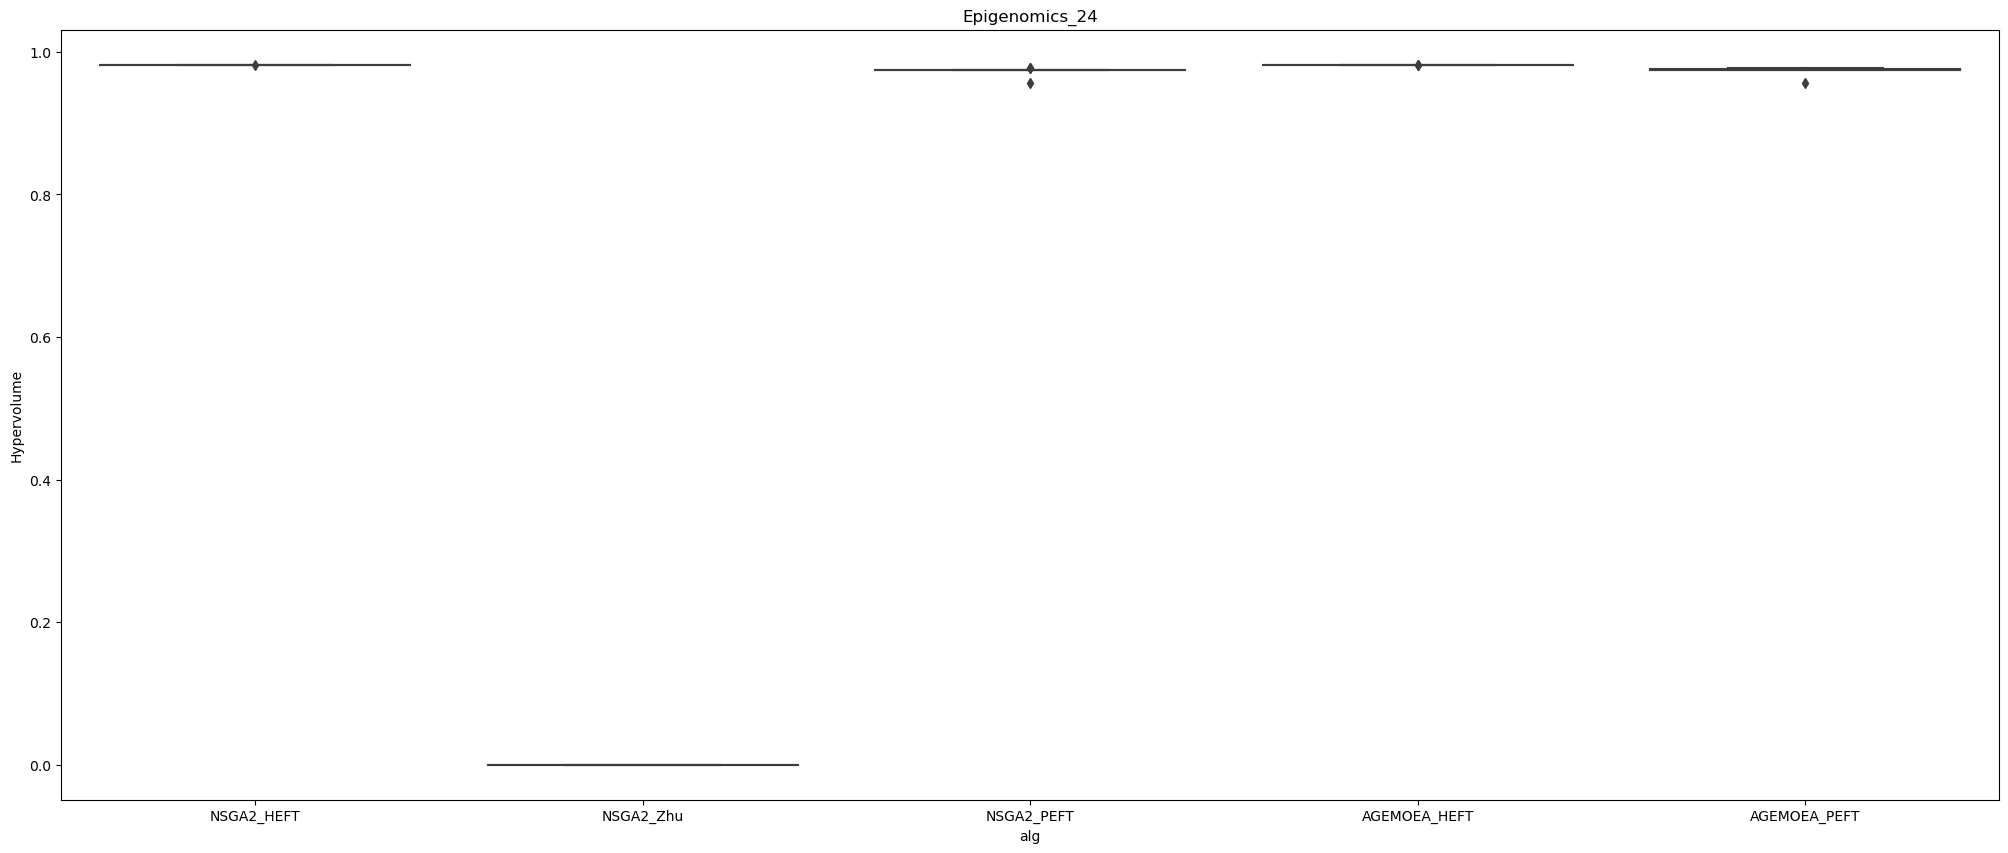

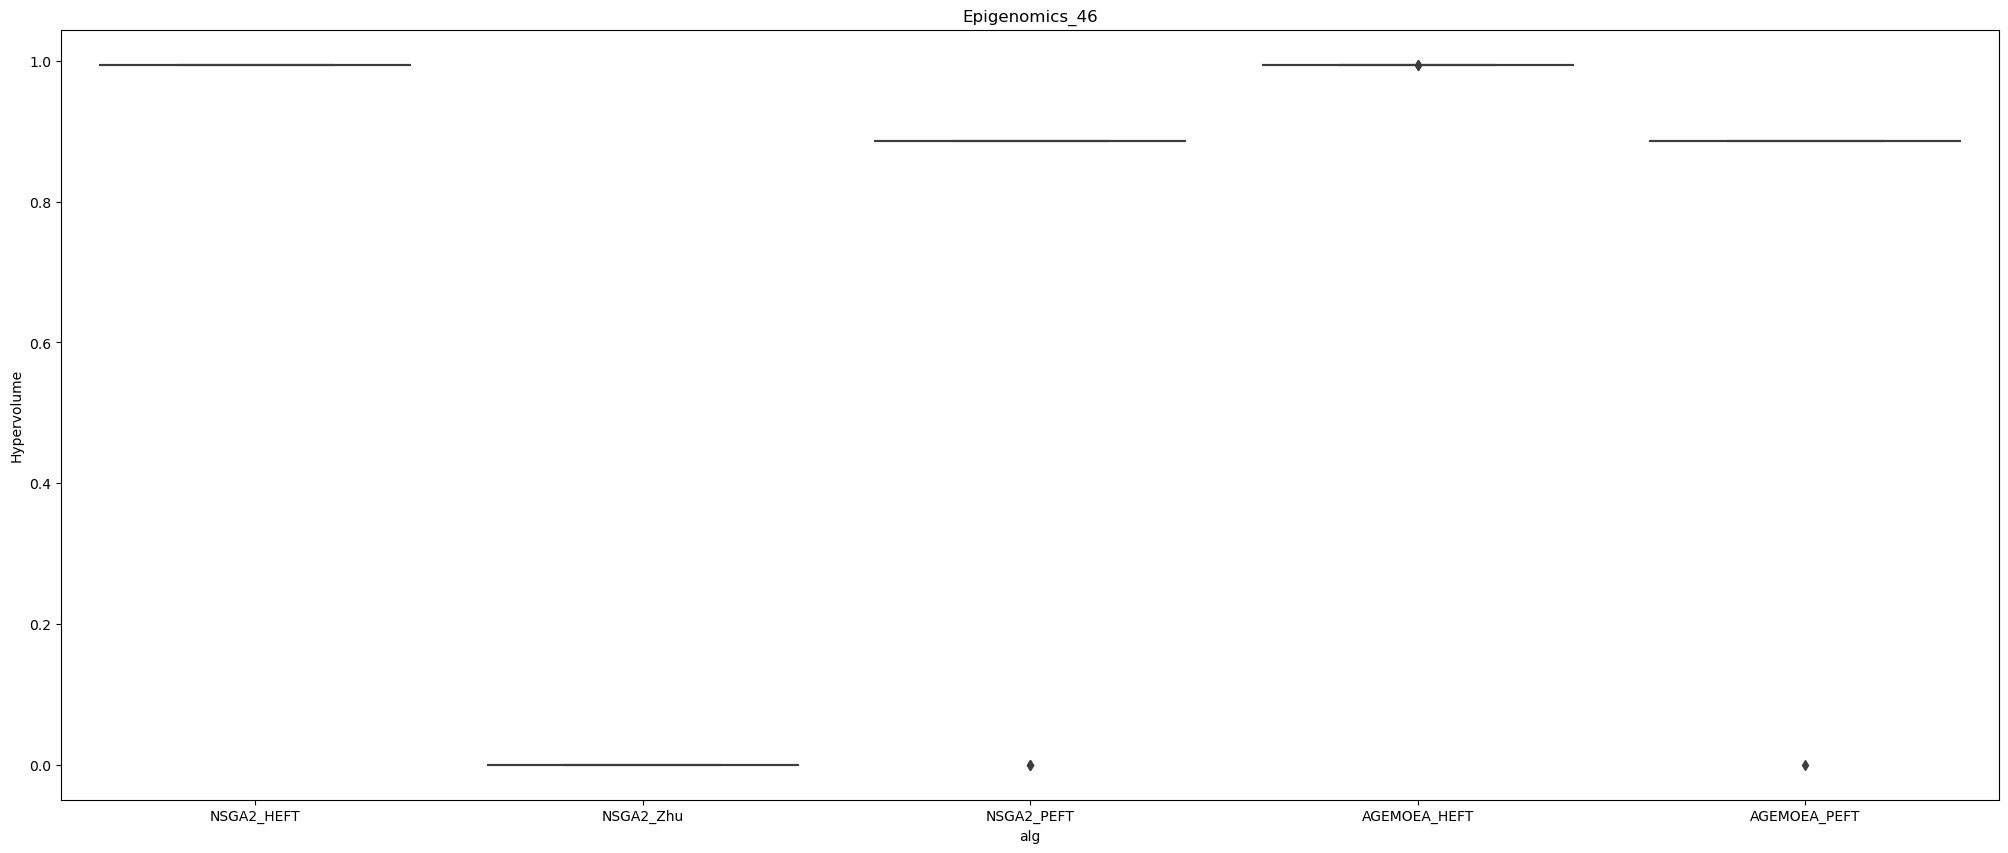

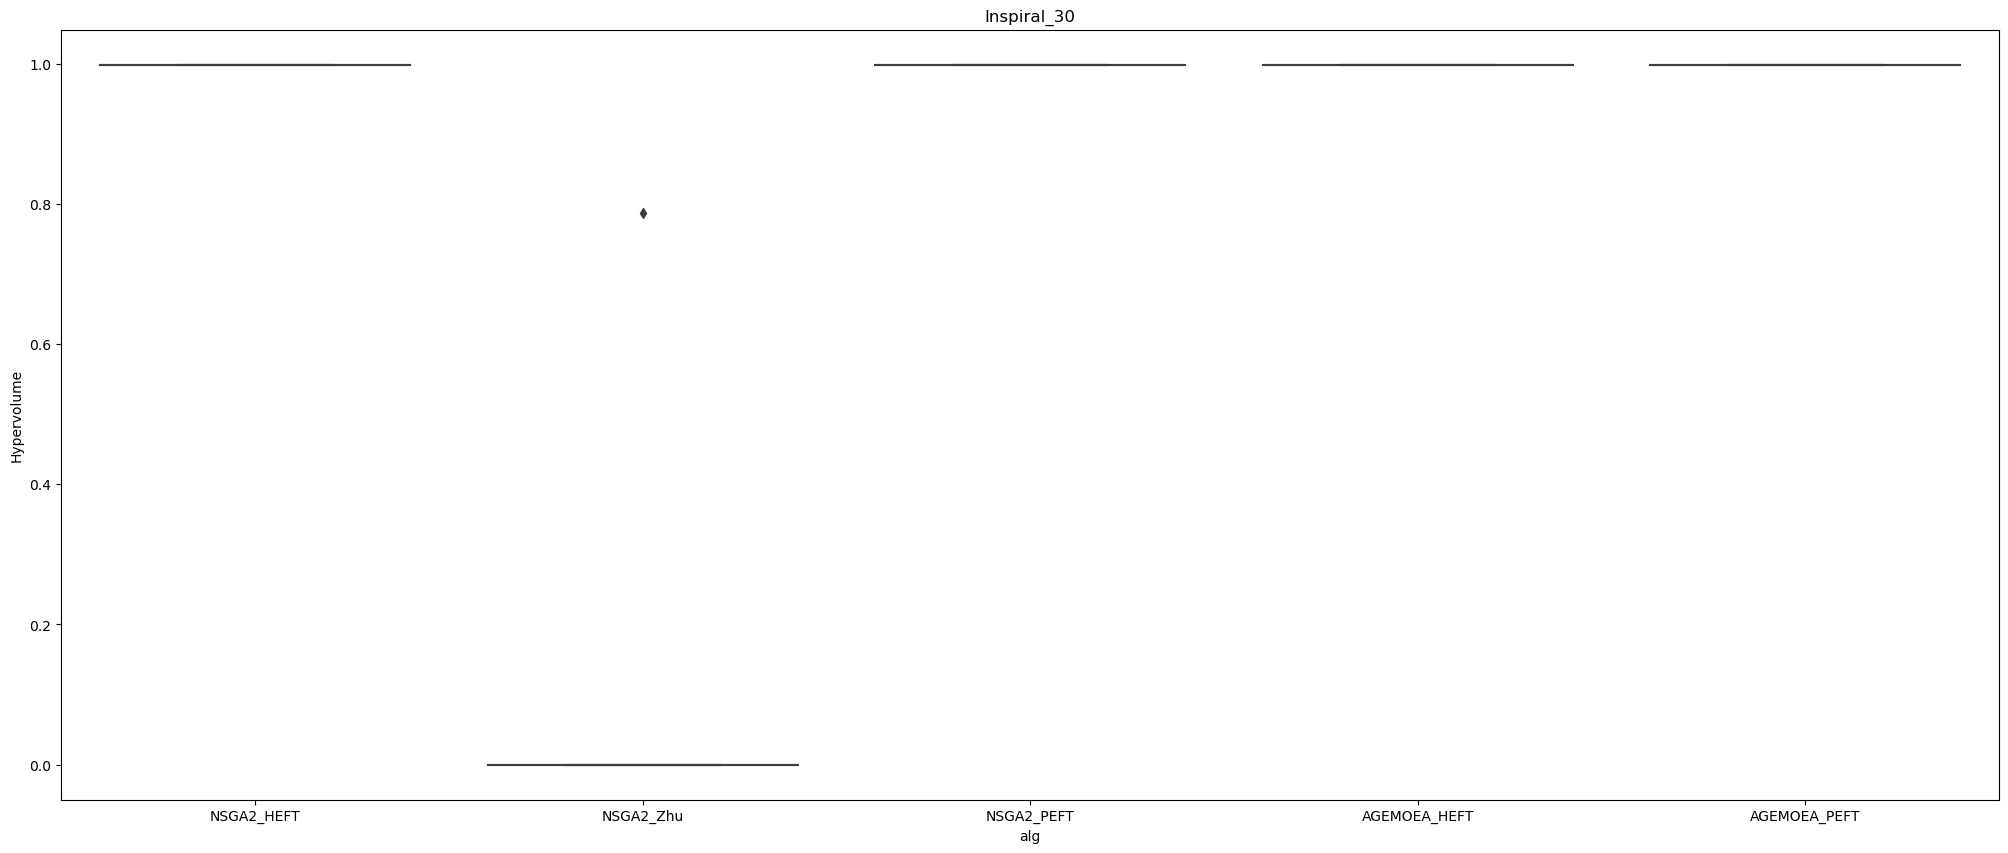

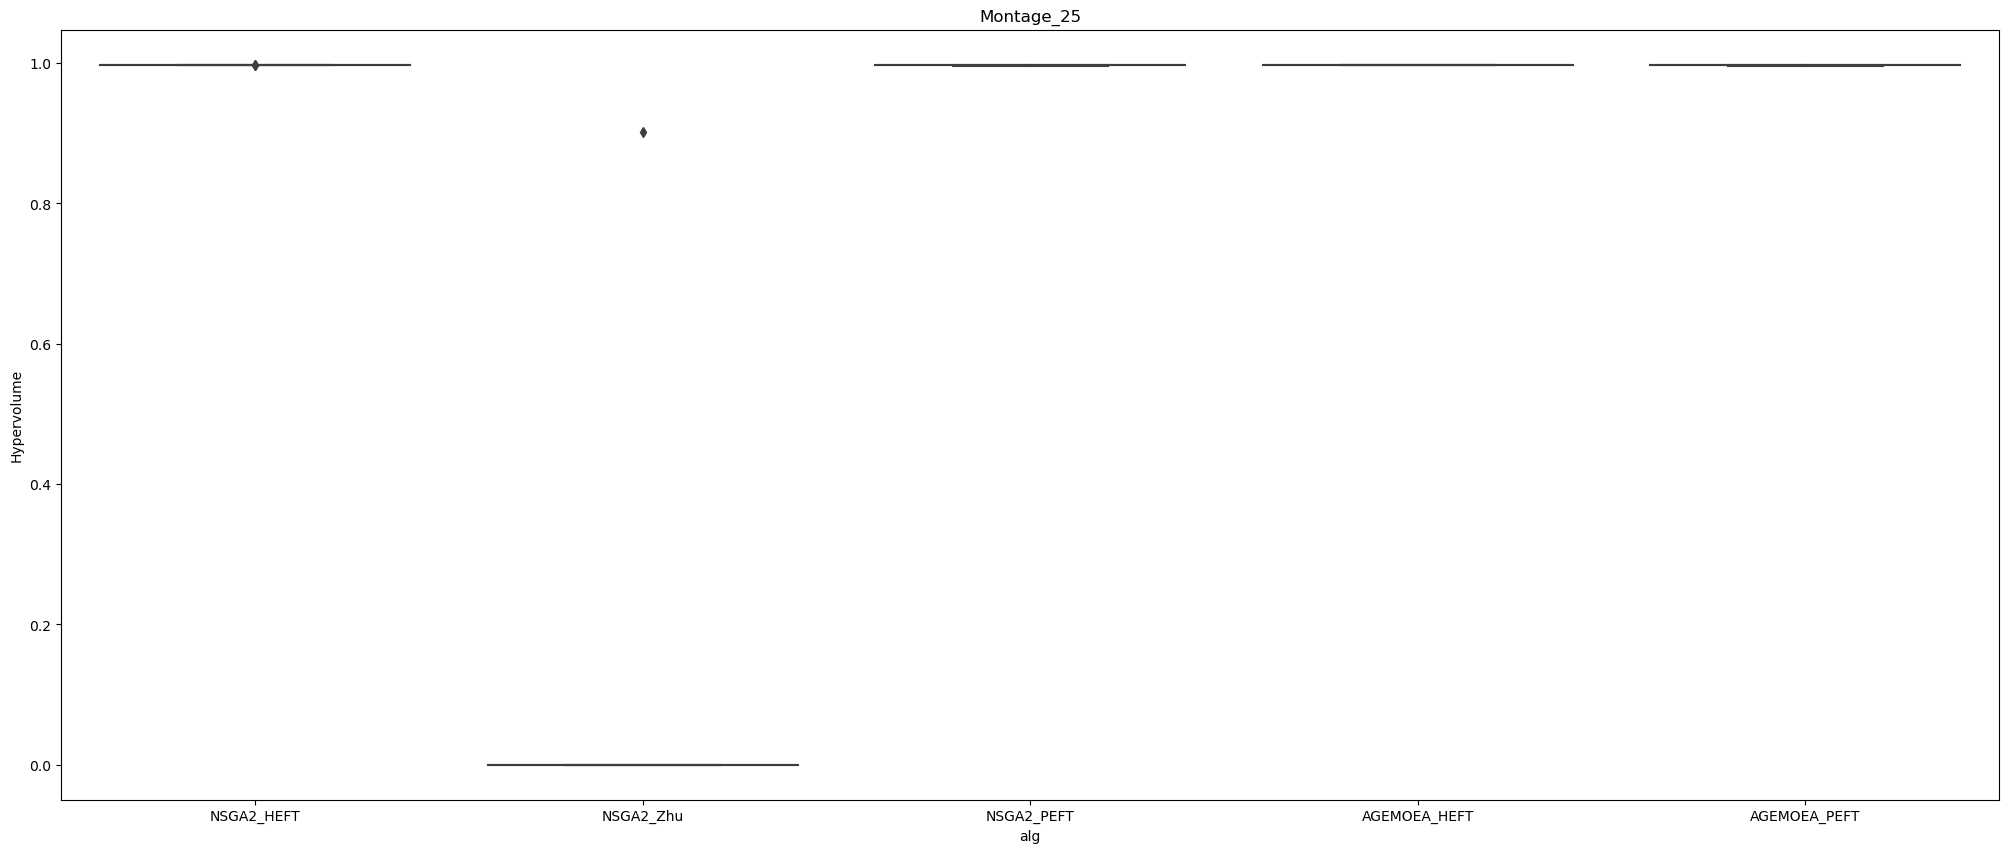

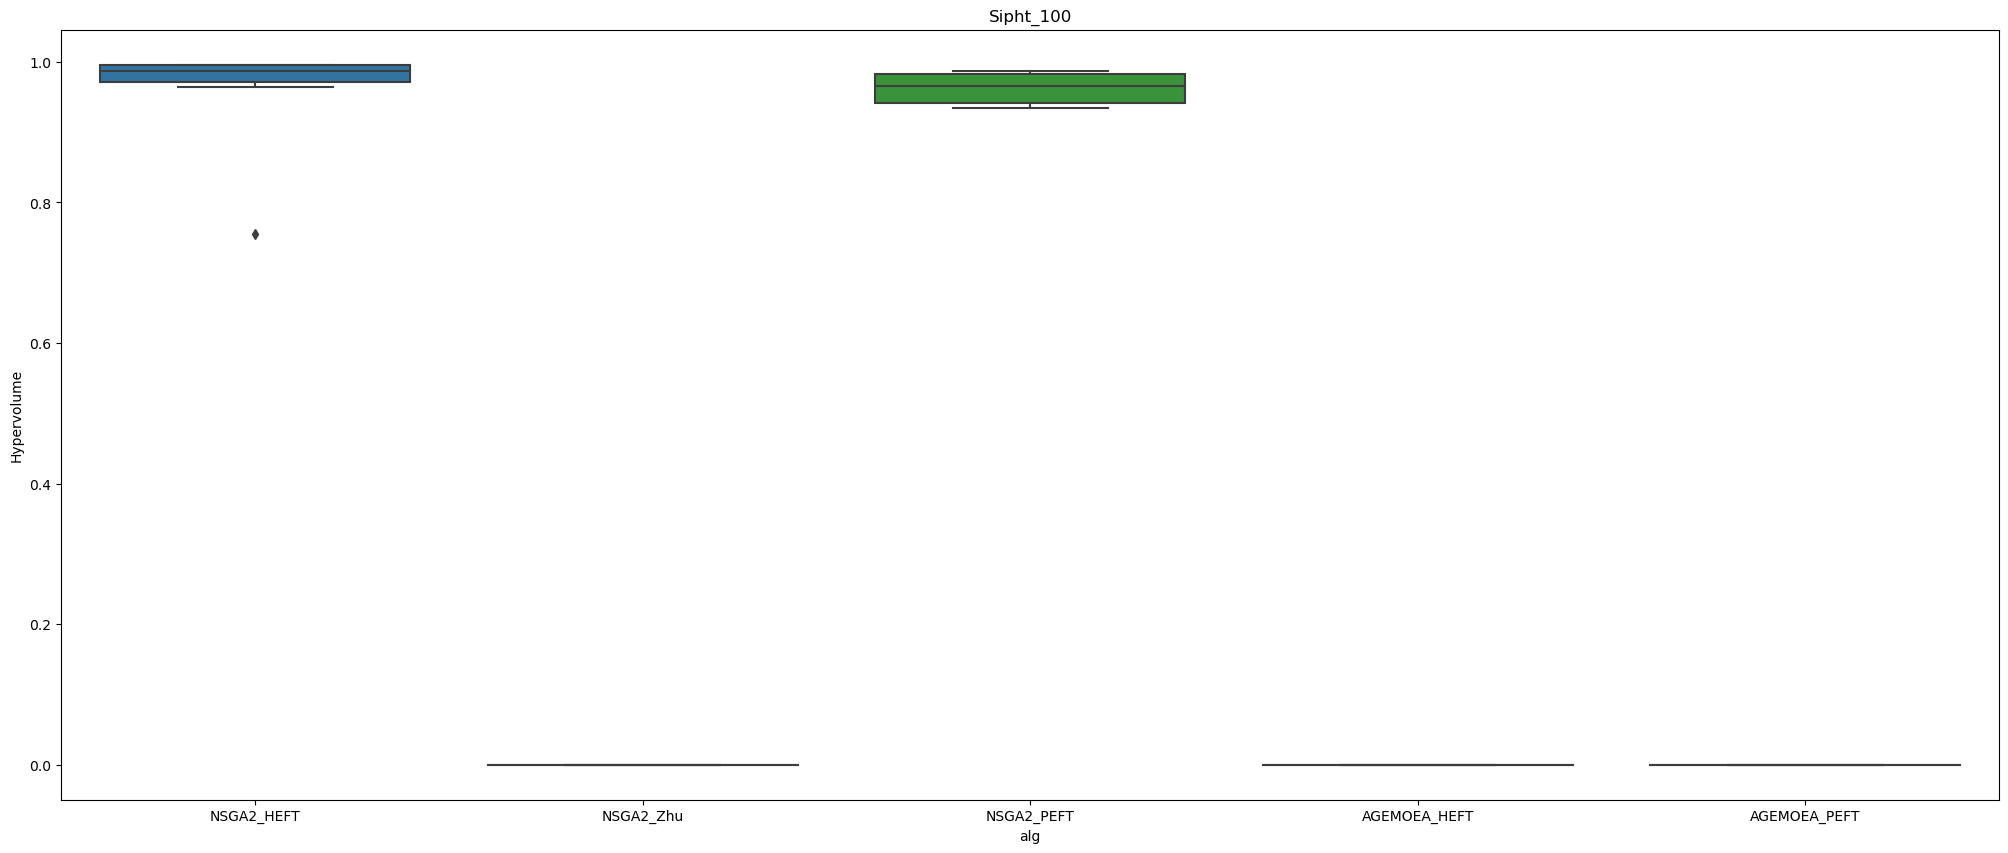

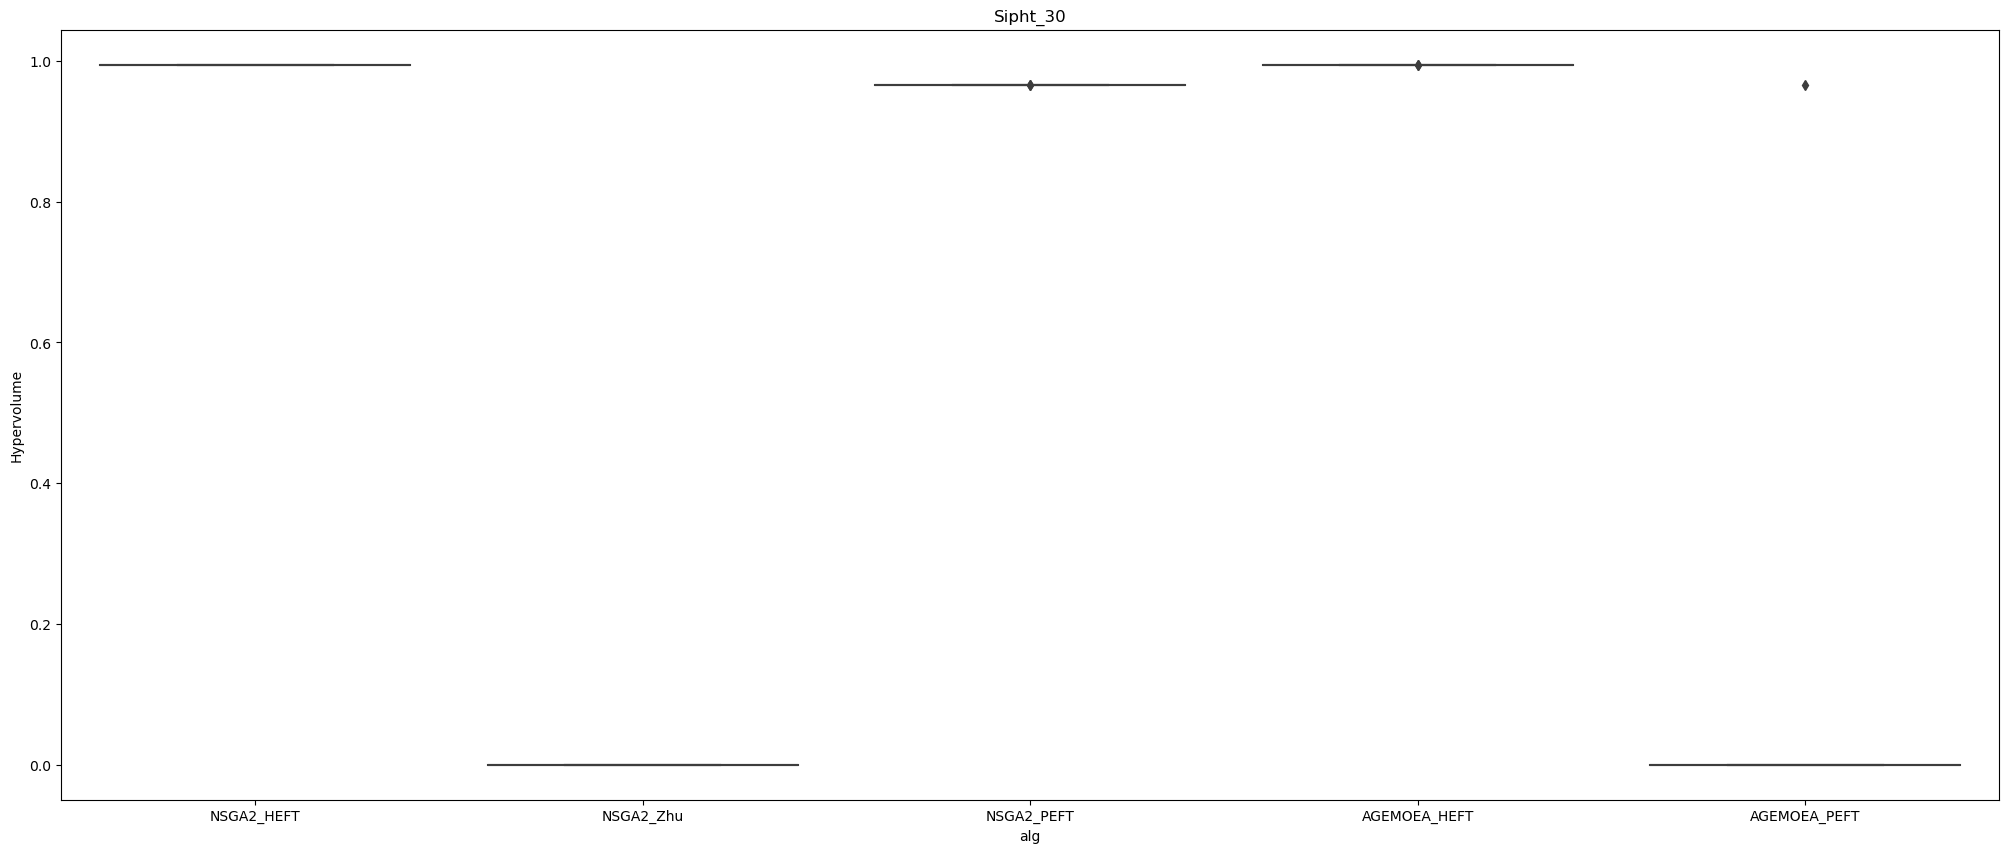

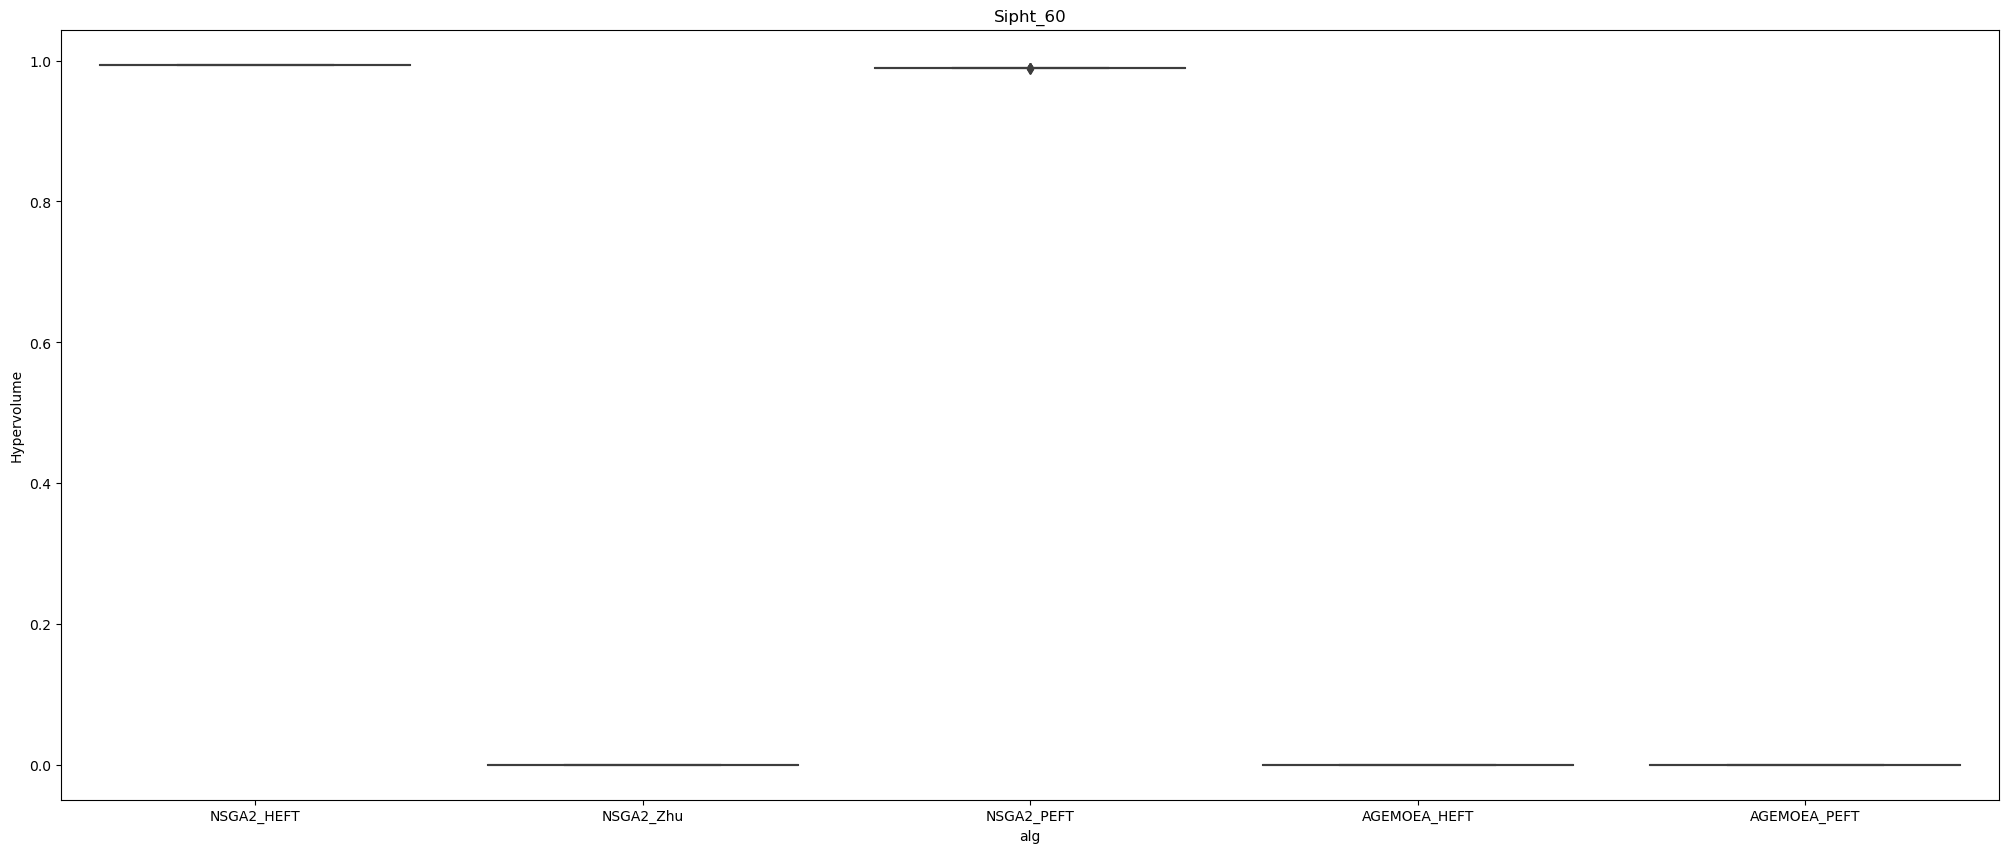

In [26]:
for problem in grouped_results.problem.unique():
    
    sub_ = results[results['problem']==problem]
    #sub_ = sub_[sub_.Hypervolume > 0]
    from pylab import rcParams
    rcParams['figure.figsize'] = 25, 10
    ax=sns.boxplot(data=sub_, y='Hypervolume', x='alg')
    ax.set_title(problem)
    plt.show()

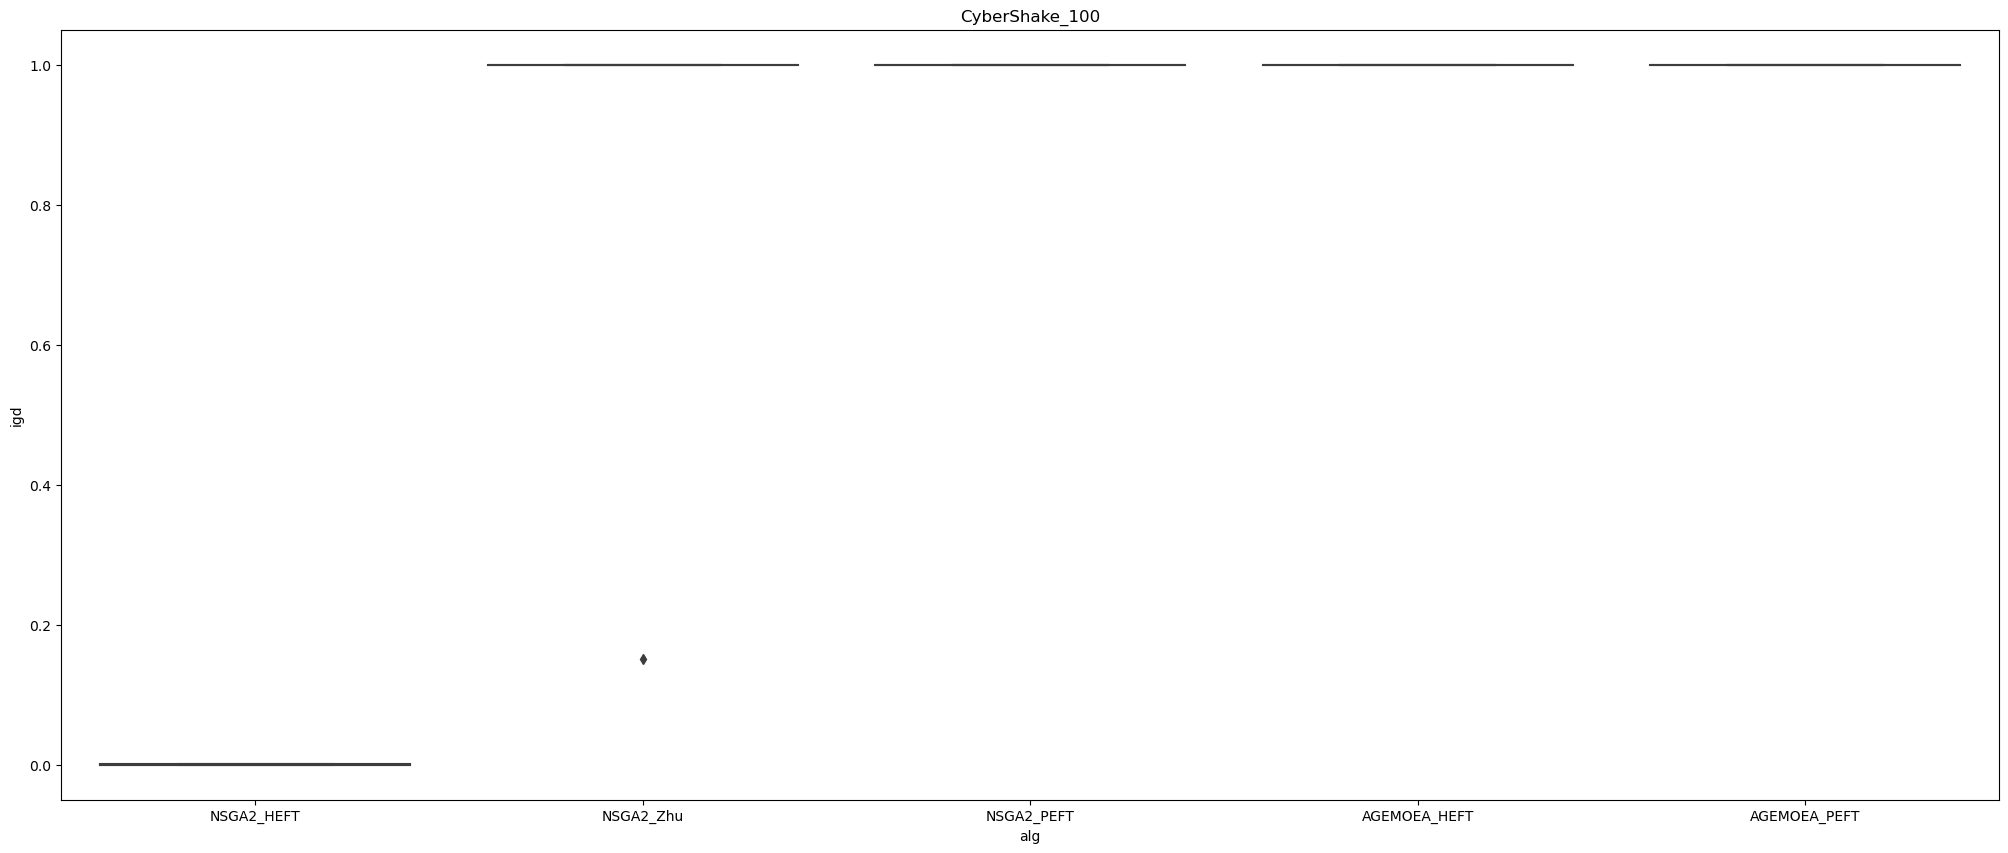

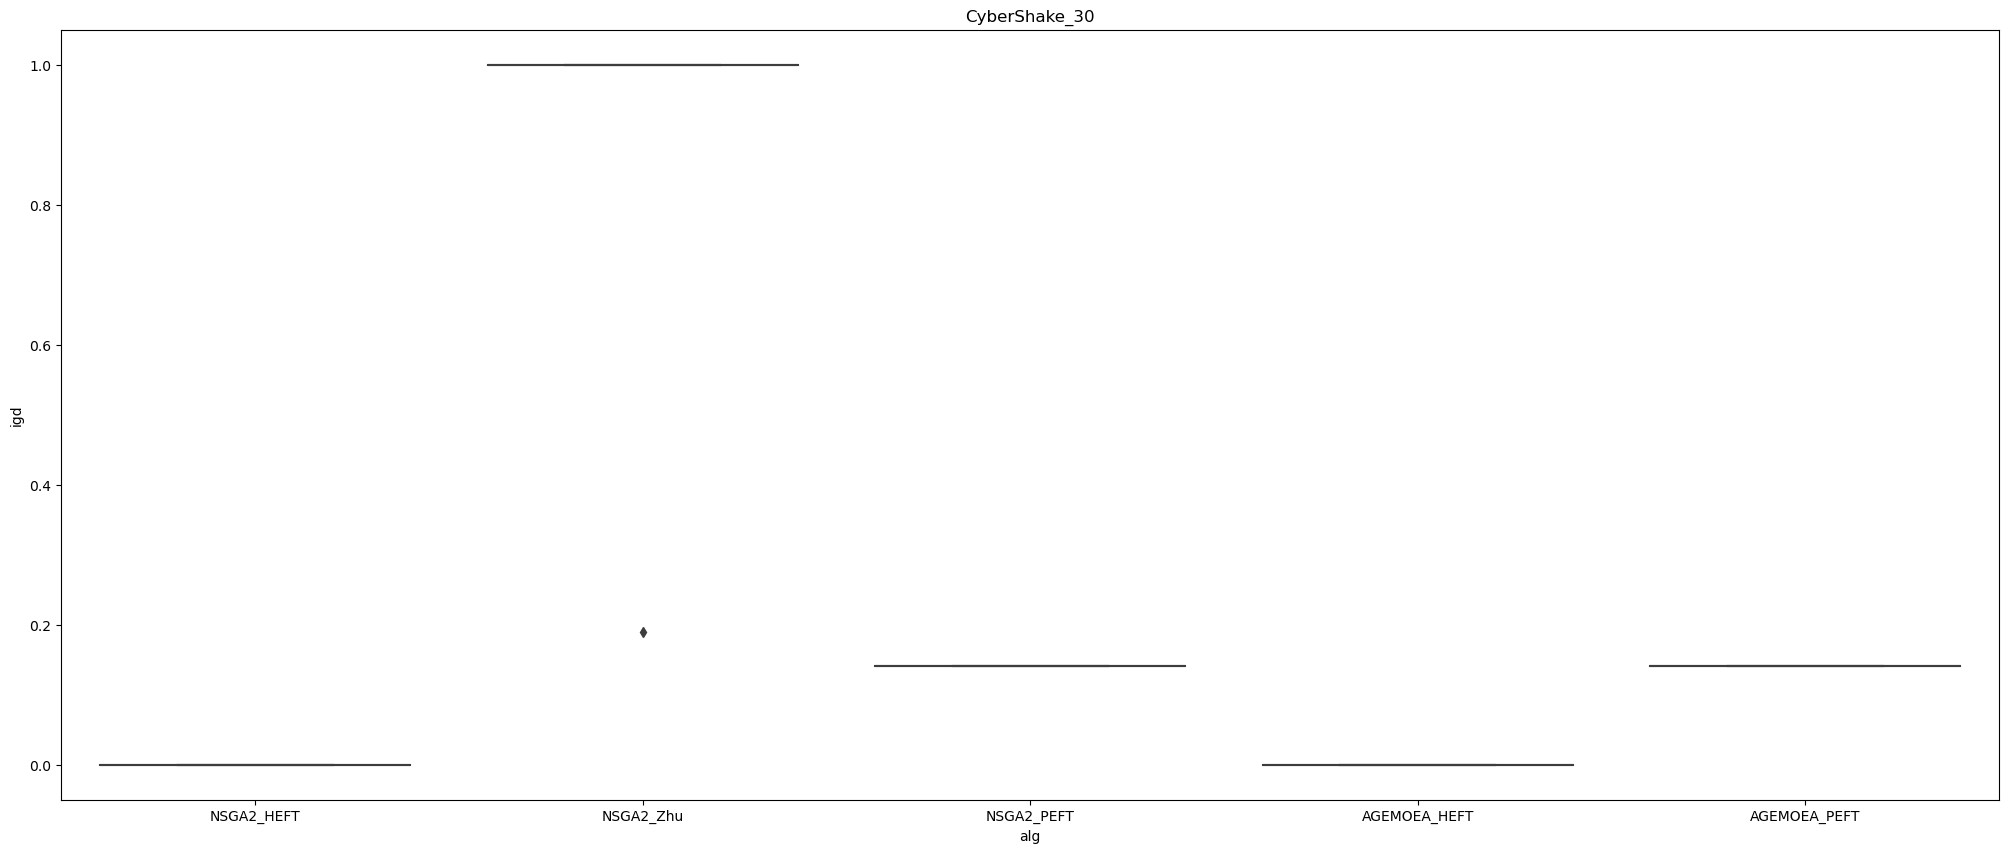

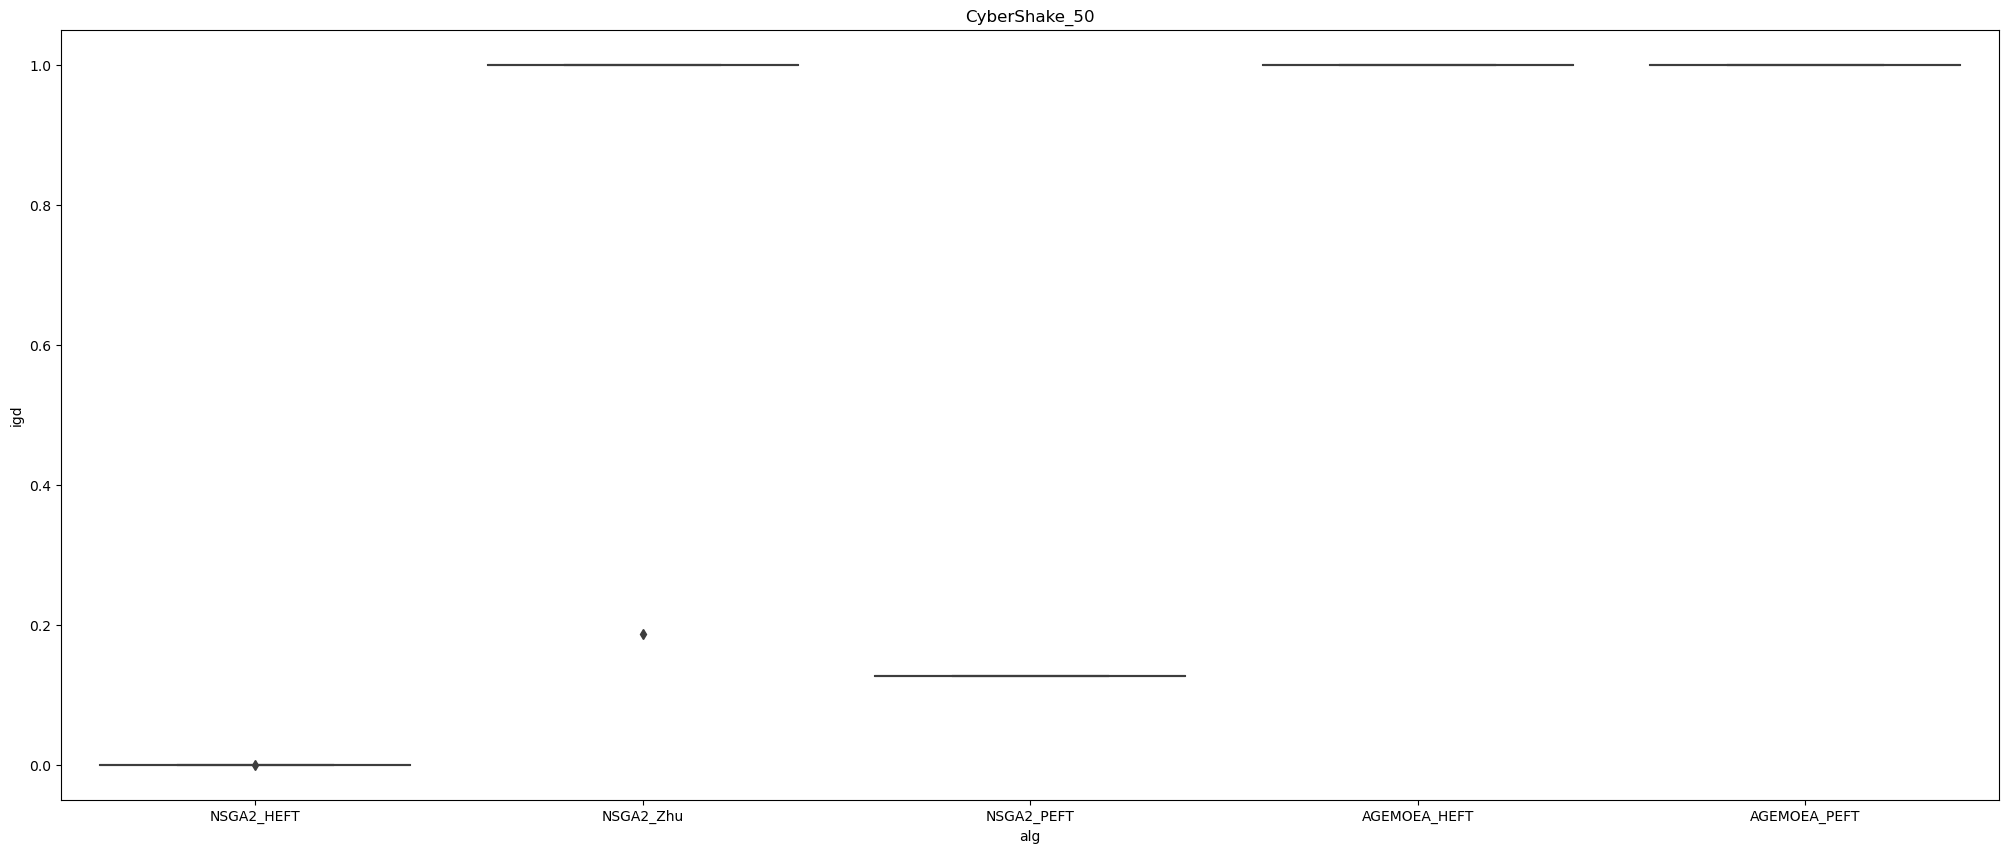

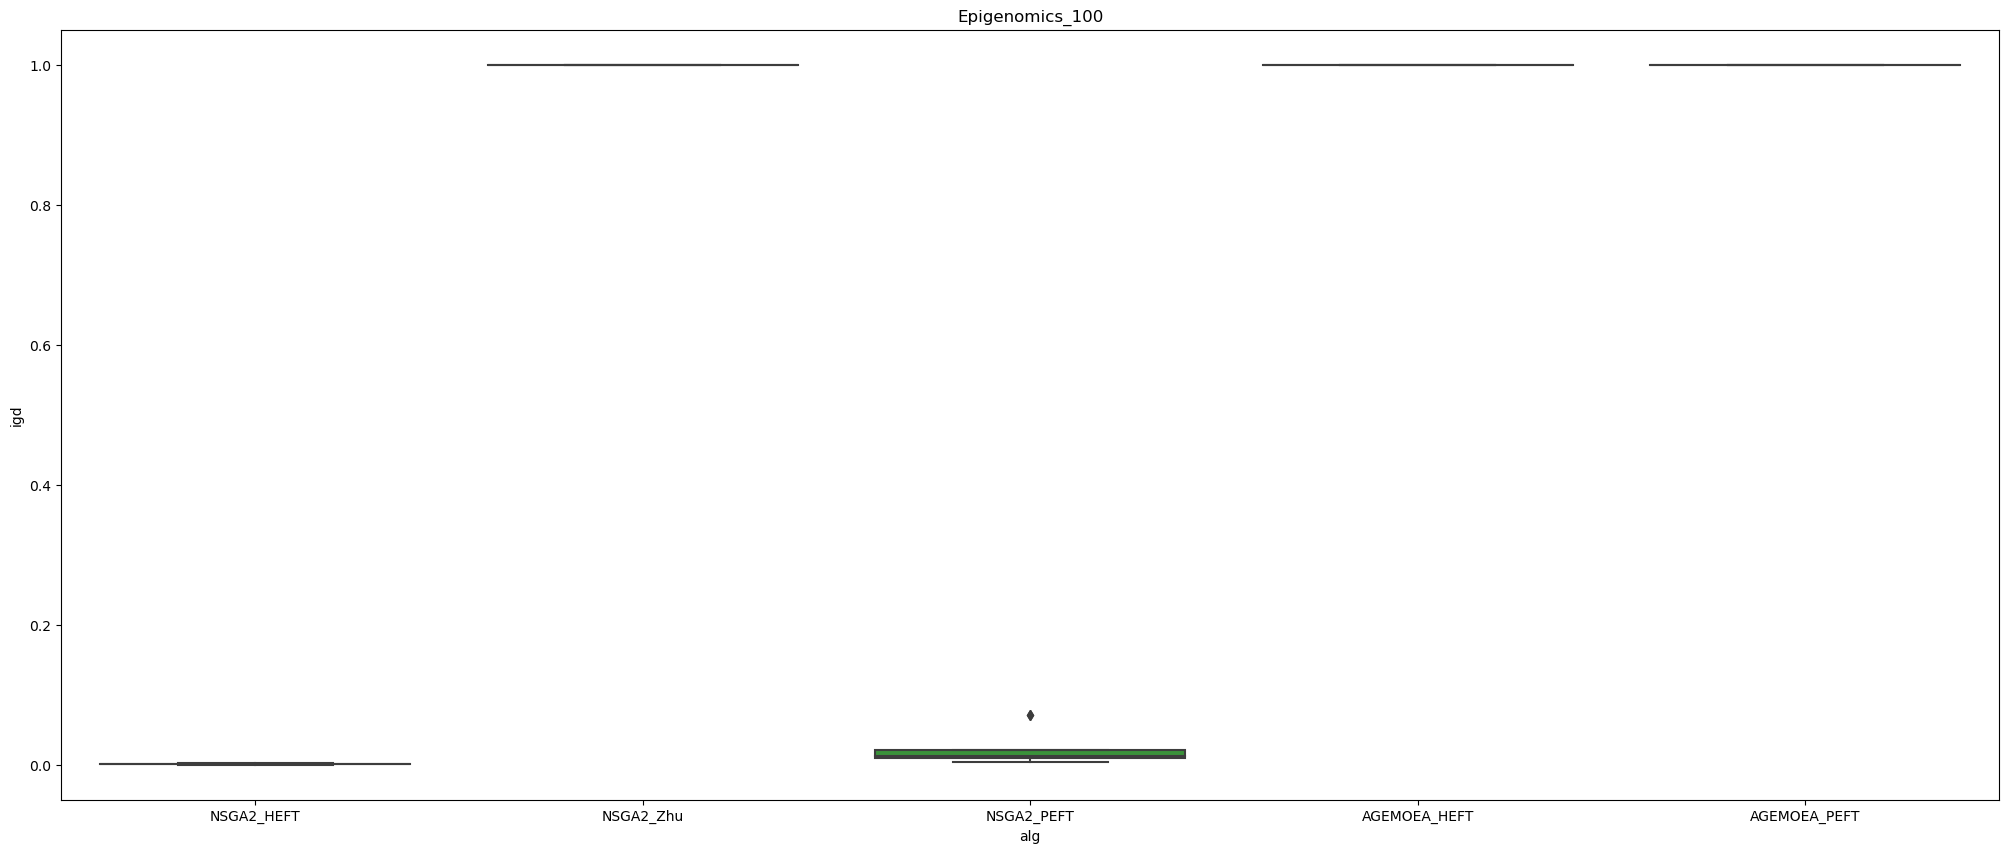

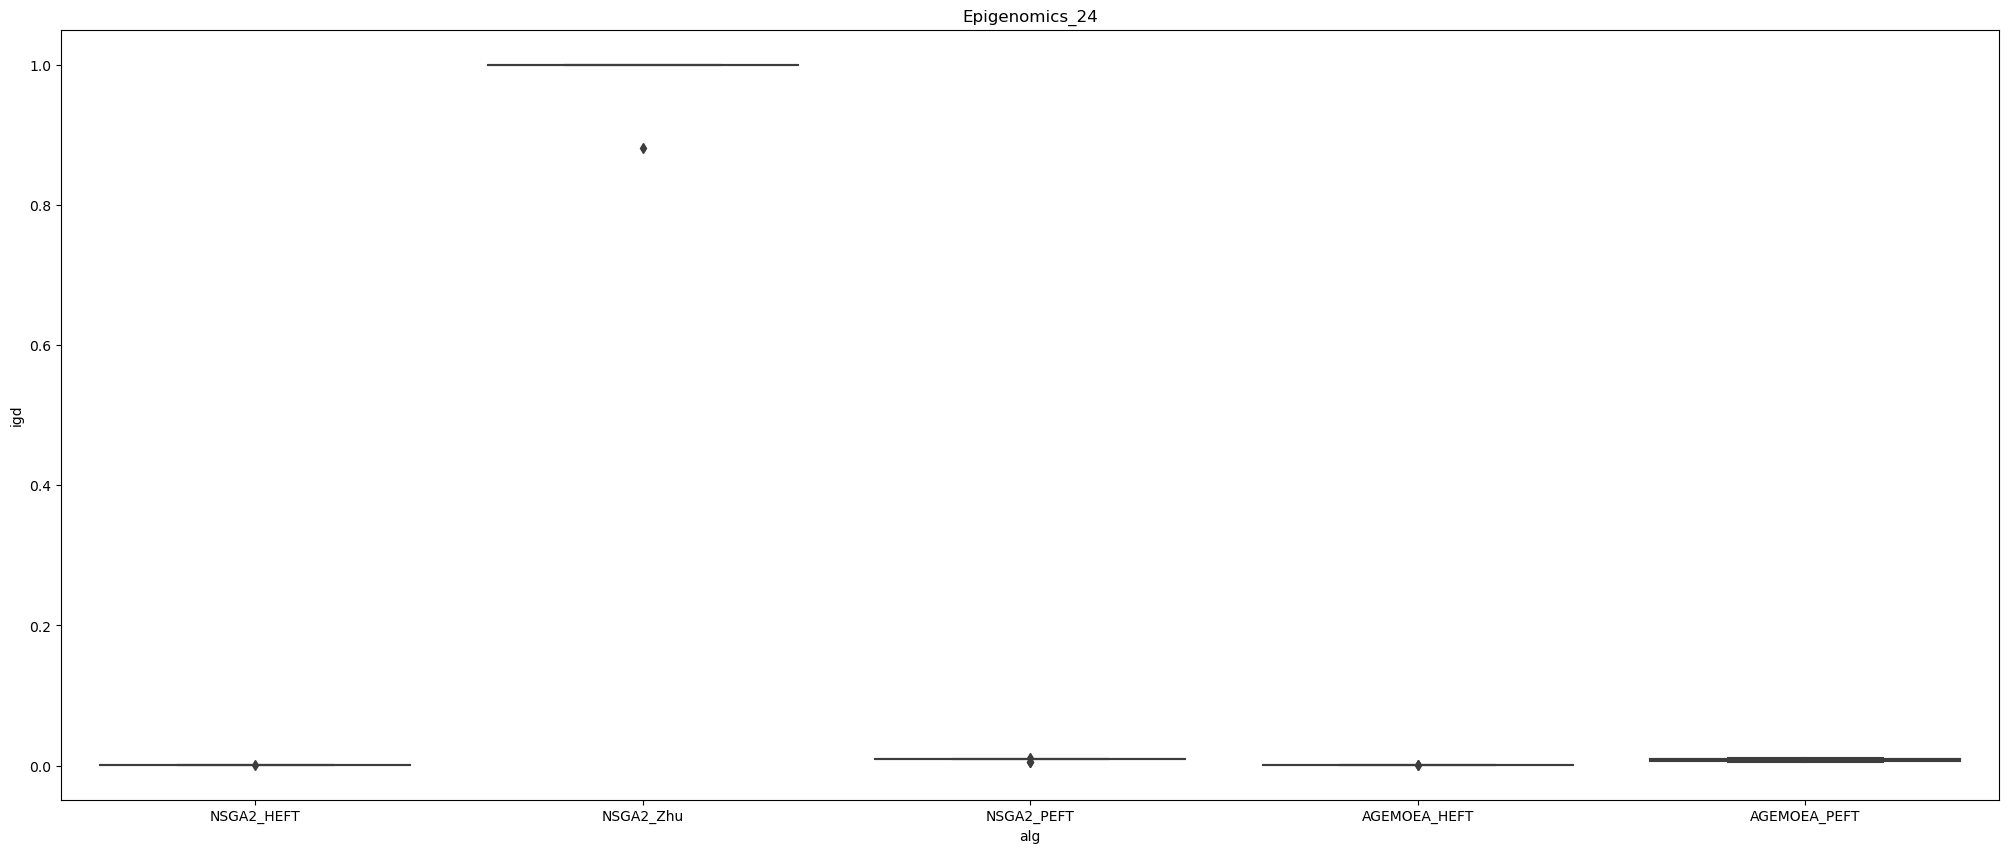

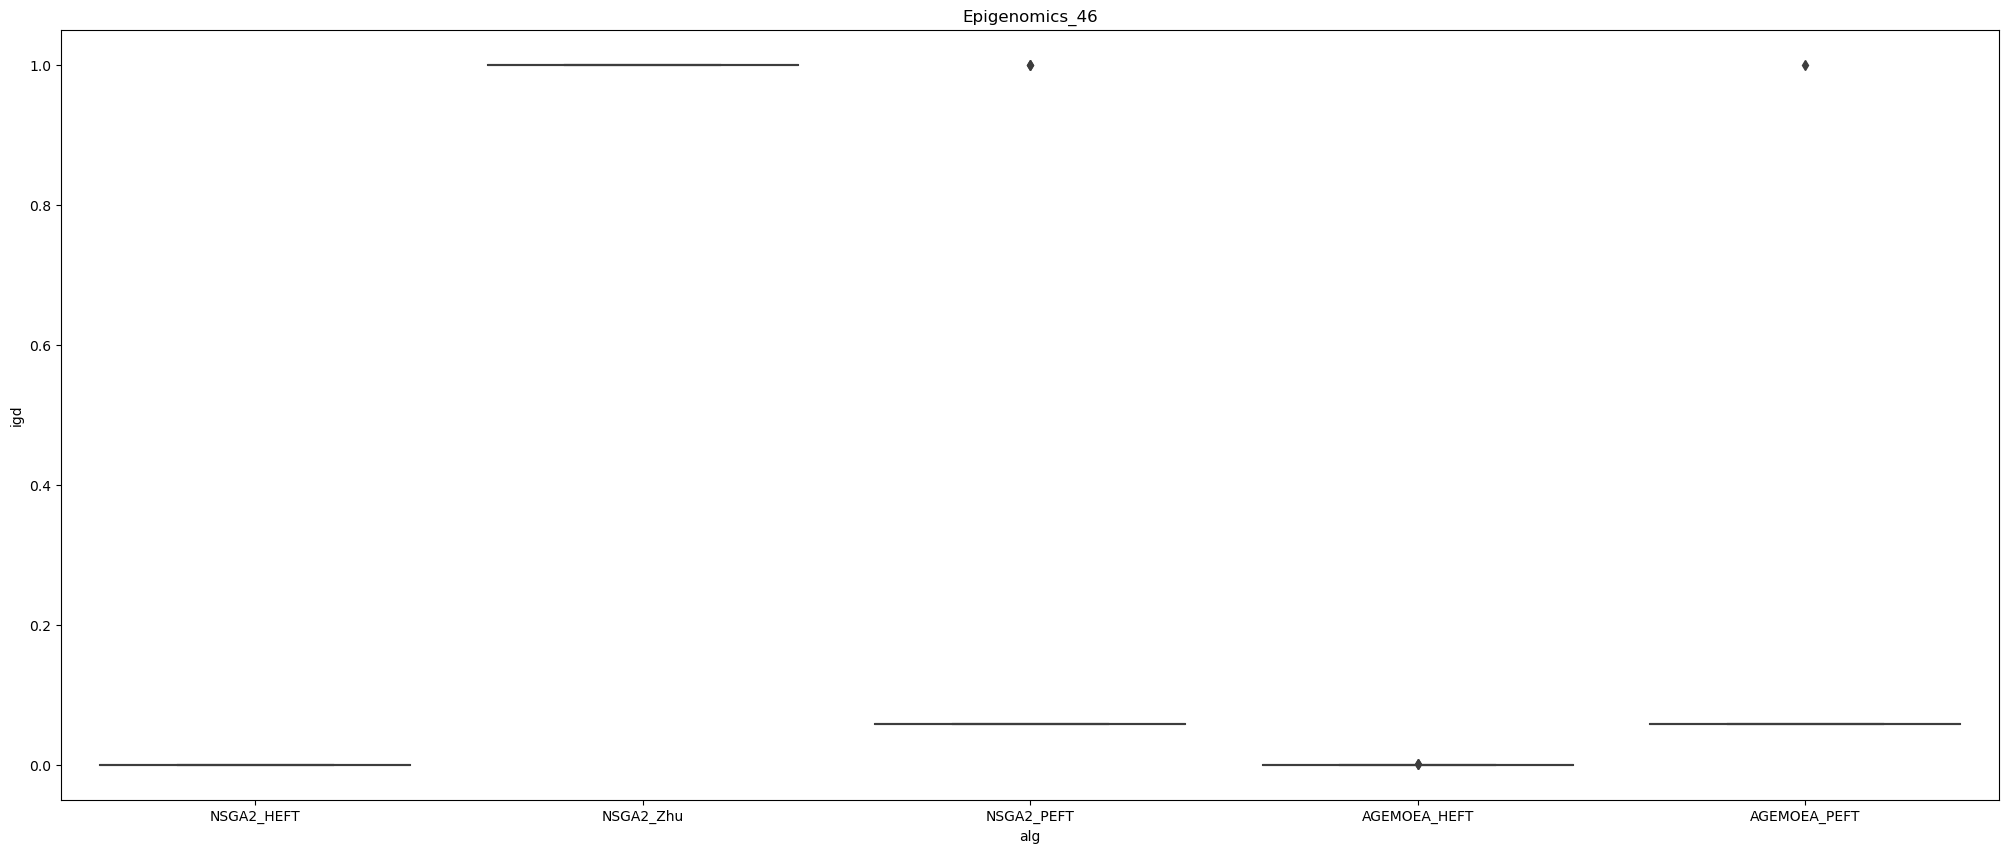

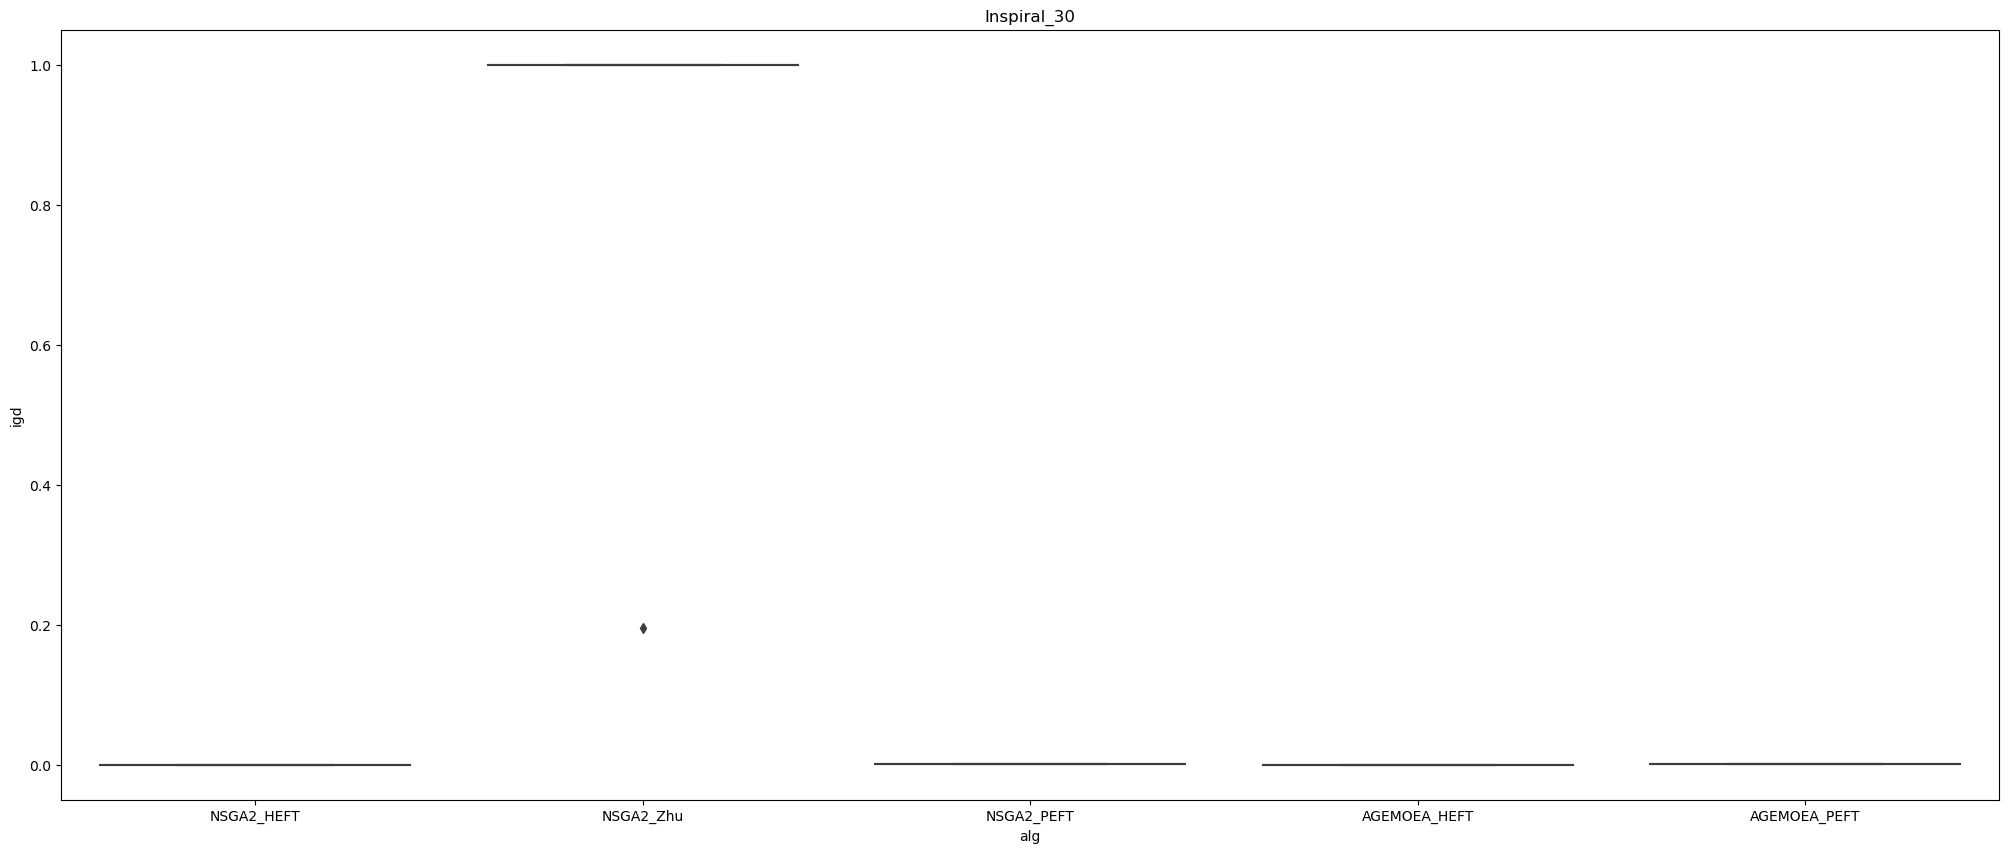

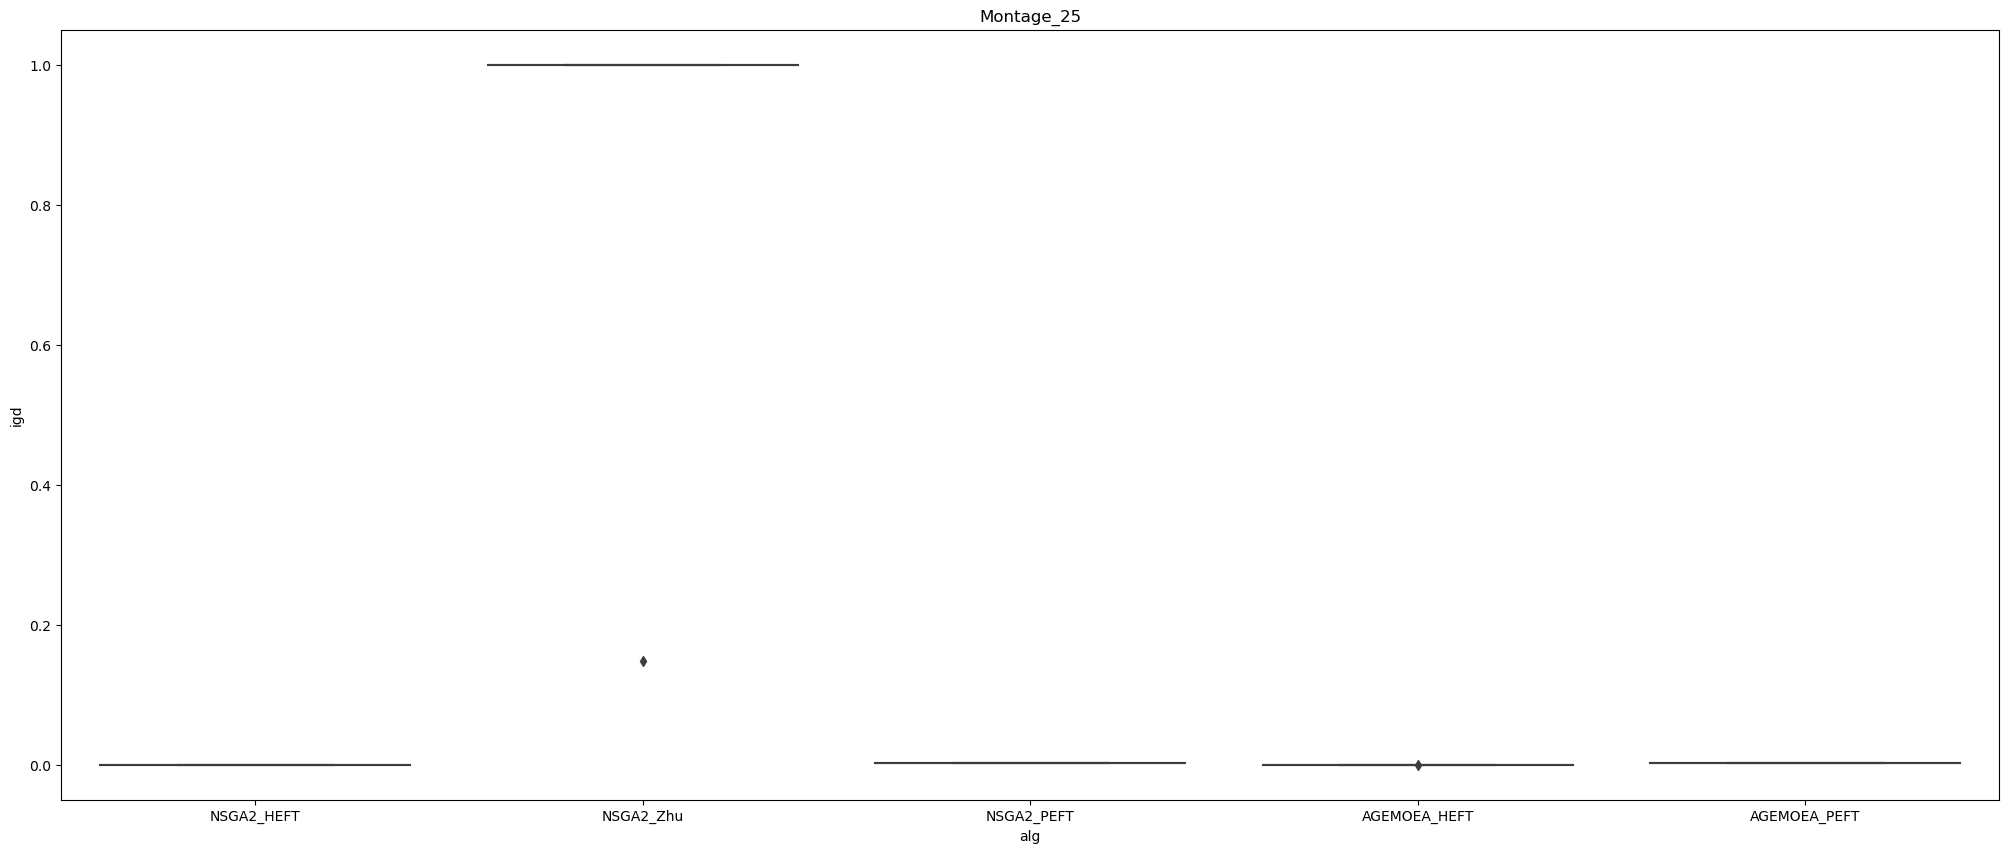

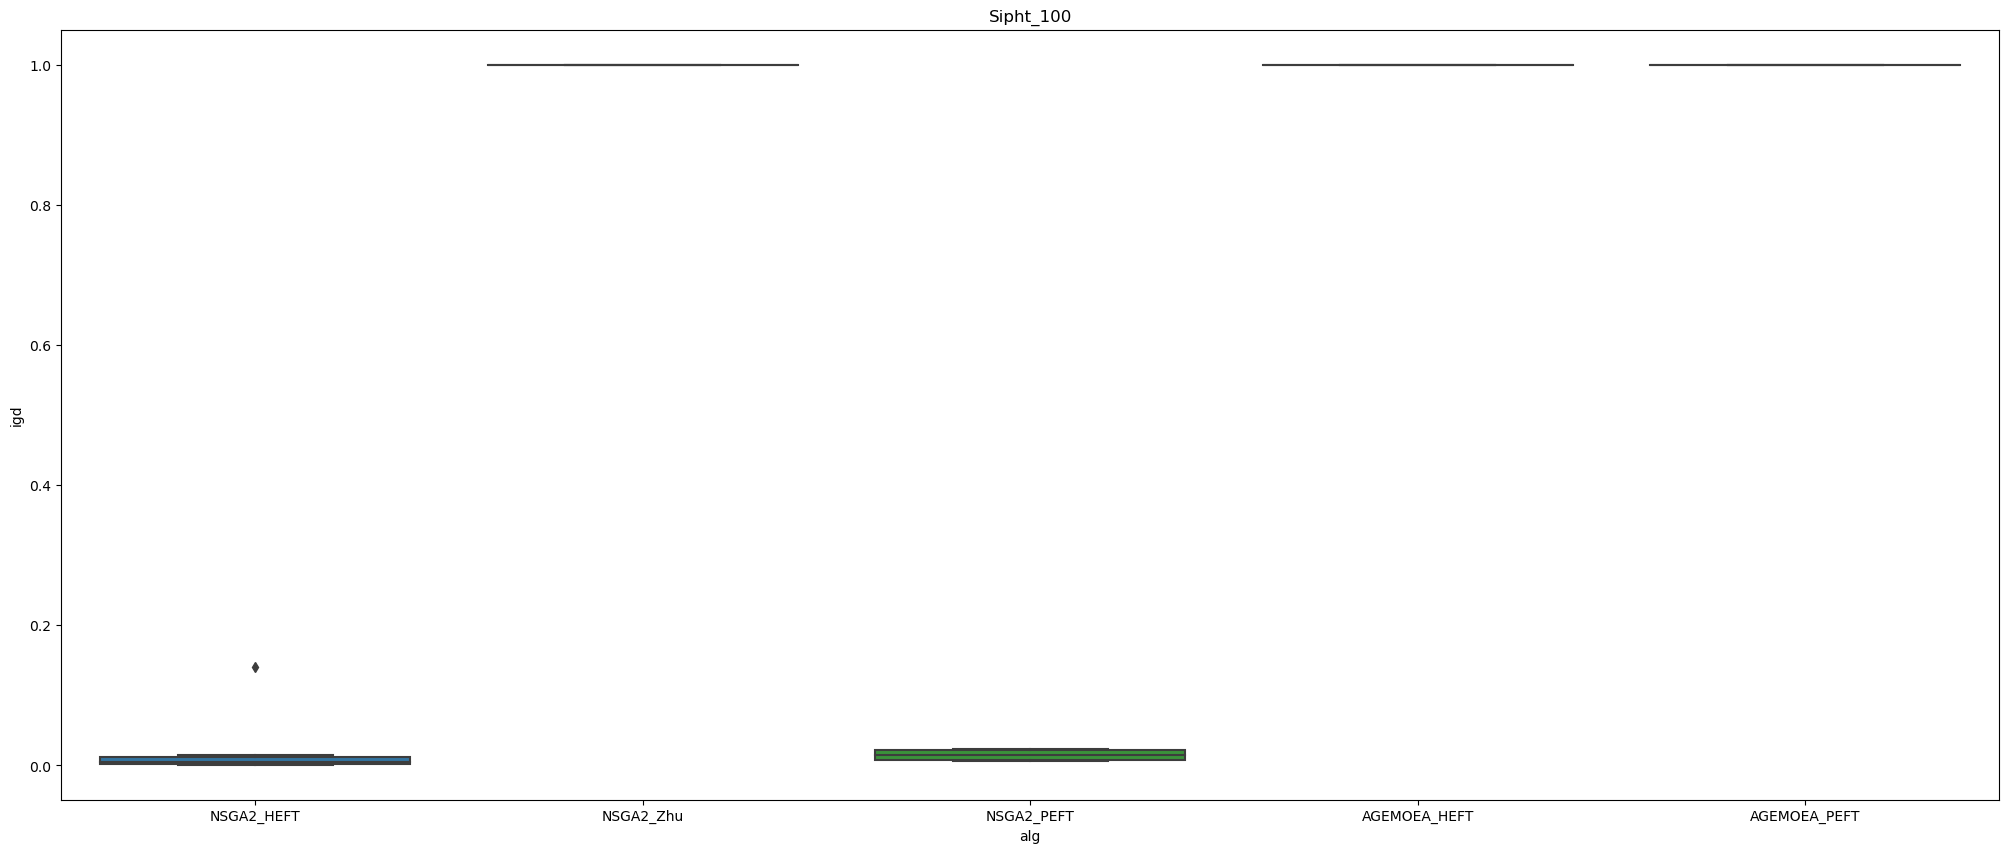

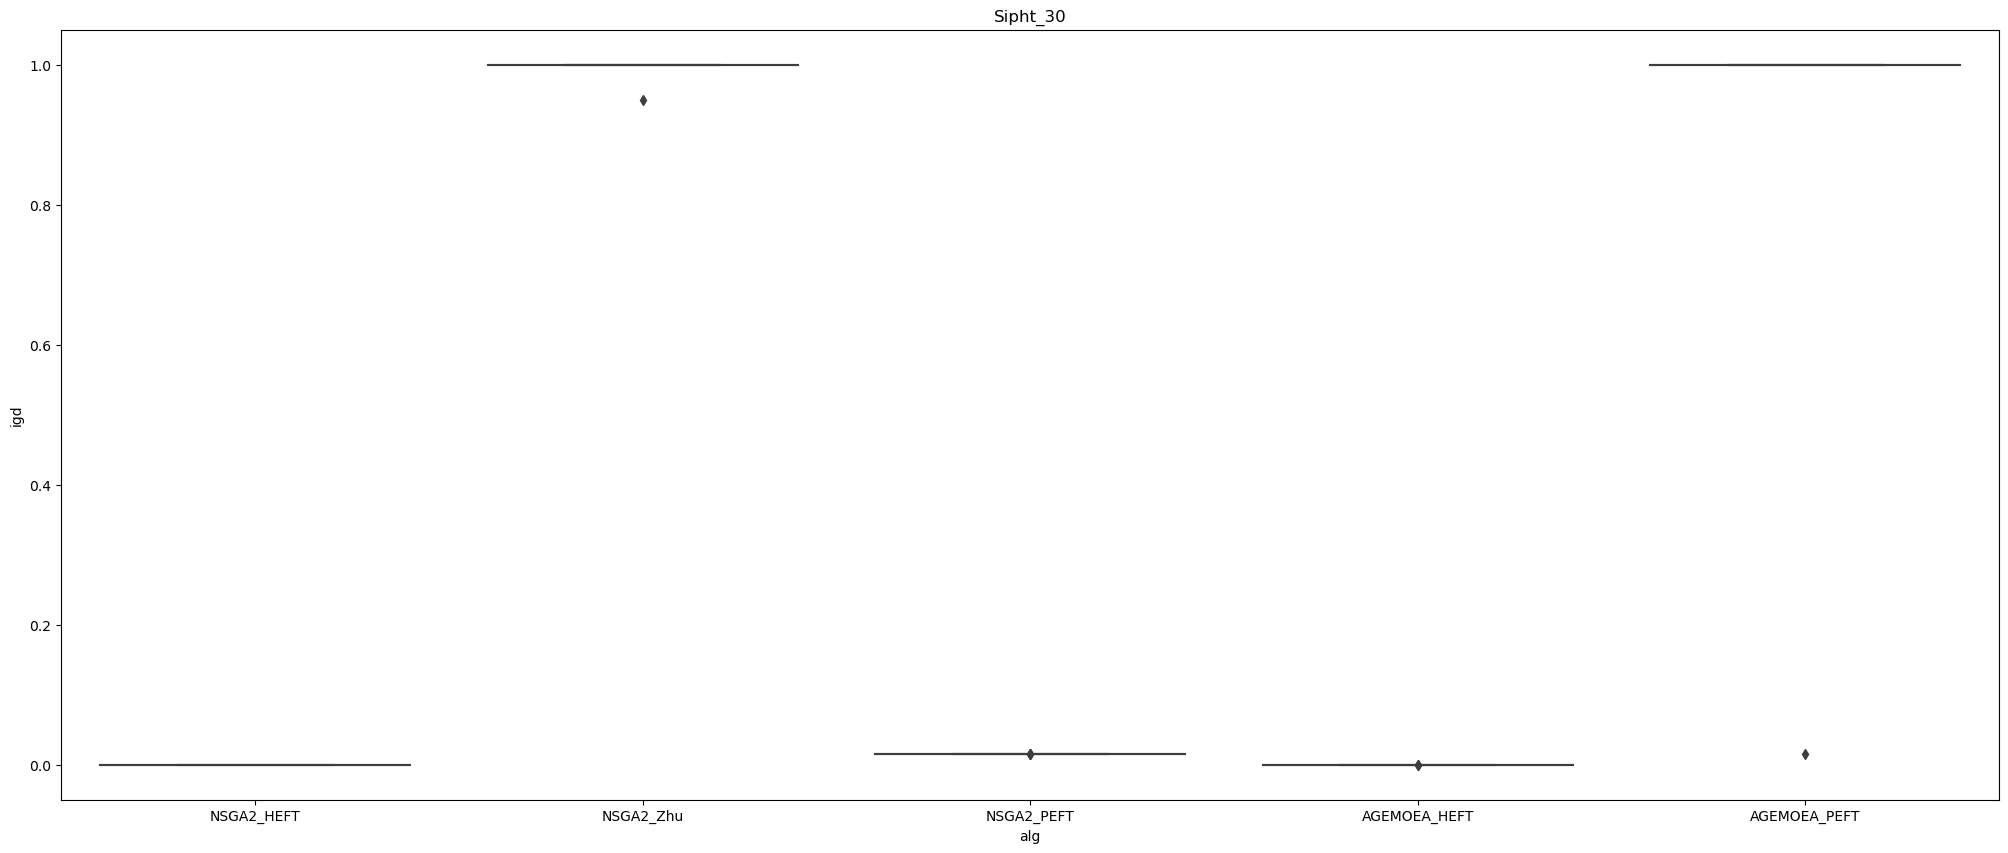

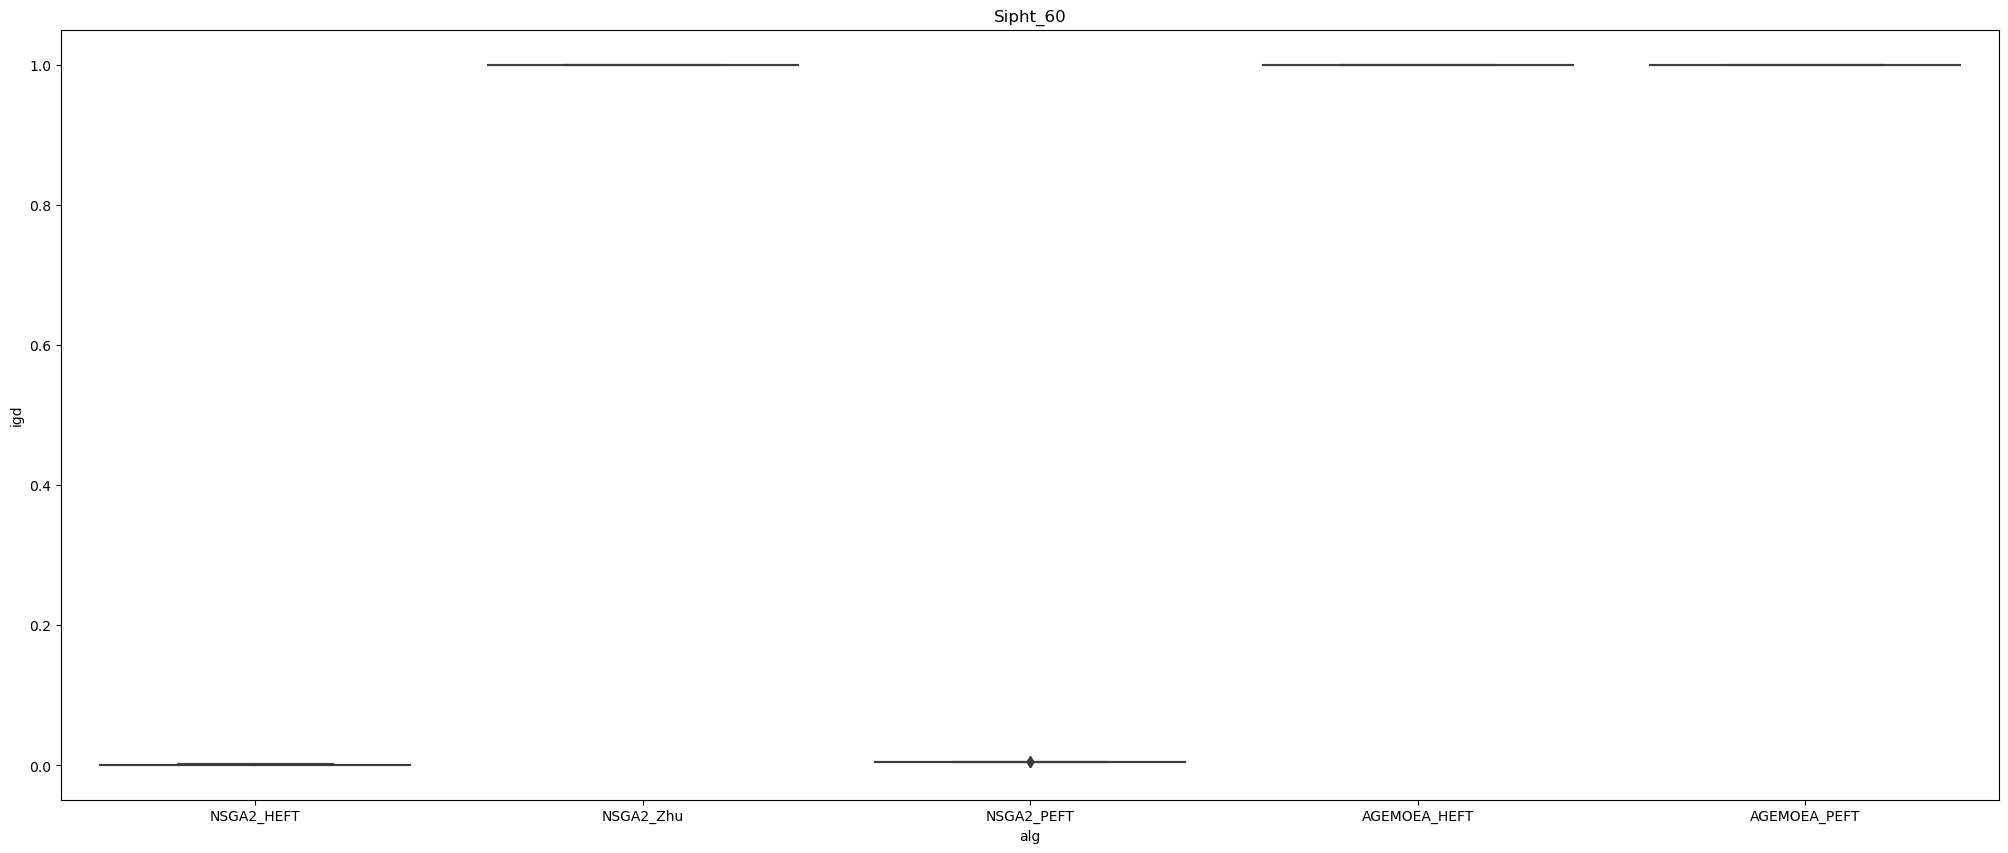

In [27]:
for problem in grouped_results.problem.unique():
    
    sub_ = results[results['problem']==problem]
    #sub_ = sub_[sub_.Hypervolume > 0]
    from pylab import rcParams
    rcParams['figure.figsize'] = 25, 10
    ax=sns.boxplot(data=sub_, y='igd', x='alg')
    ax.set_title(problem)
    plt.show()

In [28]:
sub_

,Hypervolume,problem,alg,exec,igd
495,0.994476,Sipht_60,NSGA2_HEFT,0.0,0.000978
497,0.994448,Sipht_60,NSGA2_HEFT,1.0,0.001082
498,0.994476,Sipht_60,NSGA2_HEFT,2.0,0.000978
499,0.994240,Sipht_60,NSGA2_HEFT,3.0,0.001072
500,0.994265,Sipht_60,NSGA2_HEFT,4.0,0.001118
501,0.994441,Sipht_60,NSGA2_HEFT,5.0,0.001108
502,0.994274,Sipht_60,NSGA2_HEFT,6.0,0.001092
503,0.994476,Sipht_60,NSGA2_HEFT,7.0,0.000978
504,0.994274,Sipht_60,NSGA2_HEFT,8.0,0.001092
505,0.994476,Sipht_60,NSGA2_HEFT,9.0,0.000978


In [90]:
for problem in grouped_results.problem.unique():
    sub_data = grouped_results[grouped_results['problem']==problem]
    print(sub_data[sub_data['Hypervolume']==sub_data['Hypervolume'].max()])

          problem         alg  Hypervolume  exec      igd
0  CyberShake_100  NSGA2_HEFT     0.998817   4.5  0.00023
         problem         alg  Hypervolume  exec       igd
3  CyberShake_30  NSGA2_HEFT     0.996659   4.5  0.000037
         problem         alg  Hypervolume  exec       igd
6  CyberShake_50  NSGA2_HEFT     0.998547   4.5  0.000123
           problem         alg  Hypervolume  exec       igd
9  Epigenomics_100  NSGA2_HEFT     0.987751   4.5  0.001743
           problem         alg  Hypervolume  exec       igd
12  Epigenomics_24  NSGA2_HEFT     0.982195   4.5  0.001497
           problem         alg  Hypervolume  exec       igd
15  Epigenomics_46  NSGA2_HEFT     0.994864   4.5  0.000092
        problem         alg  Hypervolume  exec       igd
18  Inspiral_30  NSGA2_HEFT     0.998555   4.5  0.000112
       problem         alg  Hypervolume  exec       igd
21  Montage_25  NSGA2_HEFT     0.997828   4.5  0.000131
      problem         alg  Hypervolume  exec       igd
25  Sipht_1

In [57]:
for problem in grouped_results.problem.unique():
    sub_data = grouped_results[grouped_results['problem']==problem]
    print(sub_data[sub_data['igd']==sub_data['igd'].min()])

          problem         alg  Hypervolume       igd
2  CyberShake_100  NSGA2_HEFT     0.907723  0.091247
           problem         alg  Hypervolume       igd
7  Epigenomics_100  NSGA2_HEFT     0.898837  0.093234


In [59]:
for problem in results.problem.unique():
    sub_data = results[results['problem']==problem]
    print(sub_data[sub_data['Hypervolume']==sub_data['Hypervolume'].max()])

    Hypervolume         problem         alg exec       igd
39     0.999055  CyberShake_100  NSGA2_HEFT    5  0.000225
    Hypervolume          problem         alg exec       igd
91     0.990196  Epigenomics_100  NSGA2_HEFT    2  0.001993
